In [1]:
# Read in the anndata object
import anndata as ad
from pathlib import Path
import numpy as np
import sys
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
from scipy.stats import spearmanr, pearsonr
import scipy.sparse as sp
from scipy.cluster.hierarchy import linkage, dendrogram
from matplotlib.ticker import ScalarFormatter
import scanpy as sc
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import cross_val_score, KFold, StratifiedKFold
from sklearn.metrics import r2_score, accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler
from collections import defaultdict
import warnings
from adjustText import adjust_text

warnings.filterwarnings('ignore')

# Import LeafletFA differential splicing code
# Define module paths
src_path = "/gpfs/commons/home/kisaev/Leaflet-private/src/"

# Add to sys.path if not already present
if src_path not in sys.path:
    sys.path.append(src_path)

# Import custom modules
import BetaDirichletFactor.differential_splicing as ds

# Import utility functions - simple direct import
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/shared_utils/')
from utils import *
from figure_plotting import *

# Import all functions from /gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/shared_utils/atse_viz.py
import sys
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/shared_utils/')
from atse_viz import *
import gffutils

mouse_db_file = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/genome_files/GENCODE_vM19"
db_mouse = gffutils.FeatureDB(mouse_db_file, keep_order=True)

# Import all functions from /gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/shared_utils/atse_viz.py
import sys
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/shared_utils/')
from atse_viz import *
import gffutils

mouse_db_file = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/genome_files/GENCODE_vM19"
db_mouse = gffutils.FeatureDB(mouse_db_file, keep_order=True)

Added /gpfs/commons/home/kisaev/LeafletFA-utils to sys.path
Visualization imports successful!


In [2]:
# =============================================================================
# CONFIGURATION - EDIT THESE VALUES ONLY
# =============================================================================

# Base directories
BASE_DIR = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/MOUSE_SPLICING_FOUNDATION"
RESULTS_BASE_DIR = "/gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results"

GE_ANNDATA_scVI_PATH = f"{BASE_DIR}/scVI/ge_adata_with_both_scvi_models_2025-08-03.h5ad"
GE_ANNDATA_NMF_PATH = f"{BASE_DIR}/NMF/ge_adata_with_NMF_standard_20_1024_2025-08-03.h5ad"

# Load GSEA scVI data (not using NMF anymore because clearly not capturing meaningful biological signal)
GSEA_scVI_PATH_nes = "/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/GE_PLOTS/MOUSE/20250803/scvi_gsea_nes_matrix.tsv"
GSEA_scVI_PATH_es = "/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/GE_PLOTS/MOUSE/20250803/scvi_gsea_es_matrix.tsv"
GSEA_full_scVI_PATH = "/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/GE_PLOTS/MOUSE/20250803/gsea_results_flat_scvi.tsv.gz"

# Load GSEA for NMF and PCA 
GSEA_NMF_PATH_nes = "/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/GE_PLOTS/MOUSE/20250803/nmf_gsea_nes_matrix.tsv"
GSEA_NMF_PATH_es = "/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/GE_PLOTS/MOUSE/20250803/nmf_gsea_es_matrix.tsv"
GSEA_full_NMF_PATH = "/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/GE_PLOTS/MOUSE/20250803/gsea_results_flat_nmf.tsv.gz"

# Load GSEA for PCA 
GSEA_PCA_PATH_nes = "/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/GE_PLOTS/MOUSE/20250803/pca_gsea_nes_matrix.tsv"
GSEA_PCA_PATH_es = "/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/GE_PLOTS/MOUSE/20250803/pca_gsea_es_matrix.tsv"
GSEA_full_PCA_PATH = "/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/GE_PLOTS/MOUSE/20250803/gsea_results_flat_pca.tsv.gz"

# Load GSEA 
GSEA_scVI_nes = pd.read_csv(GSEA_scVI_PATH_nes, sep="\t")
GSEA_scVI_es = pd.read_csv(GSEA_scVI_PATH_es, sep="\t")
GSEA_scVI_full = pd.read_csv(GSEA_full_scVI_PATH, sep="\t")

GSEA_NMF_nes = pd.read_csv(GSEA_NMF_PATH_nes, sep="\t")
GSEA_NMF_es = pd.read_csv(GSEA_NMF_PATH_es, sep="\t")
GSEA_NMF_full = pd.read_csv(GSEA_full_NMF_PATH, sep="\t")

GSEA_PCA_nes = pd.read_csv(GSEA_PCA_PATH_nes, sep="\t")
GSEA_PCA_es = pd.read_csv(GSEA_PCA_PATH_es, sep="\t")
GSEA_PCA_full = pd.read_csv(GSEA_full_PCA_PATH, sep="\t")

# Reference files
AGING_GENES_PATH = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/27857814"
RBP_FILE_PATH = "/gpfs/commons/groups/knowles_lab/Karin/VanNostrand_2020_supptable1_41586_2020_2077_MOESM3_ESM.xlsx"

ATSE_FILE_PATH = (
    f"{BASE_DIR}/ATSE_mapper/ATSE_files/MOUSE_FOUNDATION_ATSE_FILE_unanno_also_2025-07-01_00-02-00.txt.gz"
)

# Load ATSE file
print(f"Loading ATSE file from {ATSE_FILE_PATH}")
atse_df = pd.read_csv(ATSE_FILE_PATH, sep="\t")
atse_df["junction_annotation"] = "Novel_SS" 
atse_df.loc[atse_df["perfect_match_5_prime"].notna(), "junction_annotation"] = "5_prime_annotated"
atse_df.loc[atse_df["perfect_match_3_prime"].notna(), "junction_annotation"] = "3_prime_annotated"
atse_df.loc[atse_df["perfect_match_5_prime"].notna() & atse_df["perfect_match_3_prime"].notna(), "junction_annotation"] = "Both_SS_annotated"

# Load NMF data
ge_adata_nmf = ad.read_h5ad(GE_ANNDATA_NMF_PATH)
print(f"Done reading NMF anndata from {GE_ANNDATA_NMF_PATH}")

# Load scVI data
ge_adata = ad.read_h5ad(GE_ANNDATA_scVI_PATH)
print(ge_adata)
print(f"Done reading the ge_adata with scVI...")

assert np.all(ge_adata.obs_names == ge_adata_nmf.obs_names), "Cell IDs in ge_adata and ge_adata_nmf do not match or are not in the same order."
assert np.all(ge_adata.var_names == ge_adata_nmf.var_names), "Gene names in ge_adata and ge_adata_nmf do not match or are not in the same order."
ge_adata.obsm["X_nmf_standard_mb"] = ge_adata_nmf.obsm["X_nmf_standard_mb"]
ge_adata.varm["nmf_standard_mb_components"] = ge_adata_nmf.varm["nmf_standard_mb_components"]
# Add PCA loadings to ge_adata
ge_adata.obsm["X_pca"] = ge_adata_nmf.obsm["X_pca"]
ge_adata.varm["pca_loadings"] = ge_adata_nmf.varm["pca_loadings"]

print(f"Done combining gene expression into one object!")

# If ge_adata.var["gene_name"] is not in ge_adata.var_names, then add it
if "gene_name" not in ge_adata.var.columns:
    ge_adata.var["gene_name"] = ge_adata.var_names

# If ge_adata.obs doesn't have cell_id make it from cell_id_clean
if "cell_id" not in ge_adata.obs.columns:
    ge_adata.obs["cell_id"] = ge_adata.obs["cell_id_clean"]
 #   ge_adata_nmf.obs["cell_id"] = ge_adata_nmf.obs["cell_id_clean"]

Loading ATSE file from /gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/MOUSE_SPLICING_FOUNDATION/ATSE_mapper/ATSE_files/MOUSE_FOUNDATION_ATSE_FILE_unanno_also_2025-07-01_00-02-00.txt.gz
Done reading NMF anndata from /gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/MOUSE_SPLICING_FOUNDATION/NMF/ge_adata_with_NMF_standard_20_1024_2025-08-03.h5ad
AnnData object with n_obs × n_vars = 137936 × 13394
    obs: 'cell_id', 'age', 'cell_ontology_class', 'mouse.id', 'sex', 'tissue', 'dataset', 'batch', 'subtissue_clean', 'broad_cell_type', 'cell_id_index', 'specific_cell_type', 'medium_cell_type', 'cell_name', 'library_size', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_is_rRNA', 'log1p_total_counts_is_rRNA', 'pct_counts_is_rRNA', 'nuclear_score_log_norm', 'nuclear_ratio_log_norm', 'nuclear_rrna_log_norm', 'nuclear_class_log_norm', 'nuclear_score_predicted_log_norm_tms', 'nuclear_ratio_predicted_log_norm_tms', 'nuclear_rr

In [3]:
# Load aging gene lists
aging_genes_mouse, aging_genes_human = load_aging_genes(AGING_GENES_PATH)
    
# Load RBP genes
rbps = load_rbp_genes(RBP_FILE_PATH)
rbps["mouse_gene_name"] = rbps["mouse_gene_name"].str.upper()
aging_genes_mouse = [g.upper() for g in aging_genes_mouse]

# if "mouse.id" is in splice_adata.obs rename it to donor_id 
print(f"Renaming mouse.id to donor_id in splice_adata.obs")
# Update gene annotations
ge_adata.var["RBP_gene"] = ge_adata.var["gene_name"].isin(rbps["mouse_gene_name"])
ge_adata.var["Aging_gene"] = ge_adata.var["gene_name"].isin(aging_genes_mouse)
rbps = rbps["mouse_gene_name"]

Loaded 330 aging-related genes (mouse)
Loaded 330 aging-related genes (human)
Loaded 356 RNA binding proteins
Renaming mouse.id to donor_id in splice_adata.obs


In [4]:
# Main parameters to change
MODEL_TRAIN_DATE = "2025-07-30"
MODEL_ANALYSIS_DATE = "2025-07-31"
PARAM_ID = 0

# =============================================================================
# AUTO-GENERATED PATHS - DON'T EDIT BELOW THIS LINE
# =============================================================================

# Core result directories
PARAM_RESULTS_DIR = f"{RESULTS_BASE_DIR}/{MODEL_TRAIN_DATE}/{MODEL_ANALYSIS_DATE}/param_id_{PARAM_ID}"
DATA_DIR = f"{PARAM_RESULTS_DIR}/data"

# Model outputs
MODEL_OUTPUTS_DIR = f"{BASE_DIR}/Leaflet/leafletFAmodel/{MODEL_TRAIN_DATE}"
MODEL_PATH = f"{MODEL_OUTPUTS_DIR}/run_{PARAM_ID}/leafletfa_model.pkl.xz"

# Main data files
SPLICE_ADATA_PATH = f"{DATA_DIR}/splice_adata_PHI_psi_var_obs.h5ad"
PI_VALUES_PATH = f"{DATA_DIR}/PI_values.npy"
PERPLEXITY_PATH =  f"{DATA_DIR}/cell_metadata_with_perplexity_param_id_{PARAM_ID}.csv.gz"
DIFF_SPL_PATH = f"{DATA_DIR}/differential_splicing_results.csv"

# Output directory for current analysis
OUTPUT_DIR = f"{PARAM_RESULTS_DIR}/analysis_outputs"

# =============================================================================
# LOAD DATA USING CONFIGURED PATHS
# =============================================================================

print(f"Loading data for param_id {PARAM_ID} from {MODEL_TRAIN_DATE}")
print(f"Data directory: {DATA_DIR}")

# Load main datasets
splice_adata = ad.read_h5ad(SPLICE_ADATA_PATH)
assert np.all(ge_adata.obs["cell_id"].values == splice_adata.obs["cell_id"].values), "Cell IDs in ge_adata and splice_adata do not match or are not in the same order."

# if "mouse.id" is in splice_adata.obs rename it to donor_id 
if "mouse.id" in splice_adata.obs.columns:
    print(f"Renaming mouse.id to donor_id in splice_adata.obs")
    splice_adata.obs.rename(columns={"mouse.id": "donor_id"}, inplace=True)

# Fix the sex column in the anndatas
sex_str = splice_adata.obs["sex"].astype(str)

# Step 2: Replace "M" → "male", "F" → "female"
sex_fixed = sex_str.replace({"M": "male", "F": "female"})

# Step 3: Convert back to categorical (optional)
splice_adata.obs["sex"] = pd.Categorical(sex_fixed)
print(splice_adata.obs["sex"].value_counts())

pi = np.load(PI_VALUES_PATH)
diff_spl = pd.read_csv(DIFF_SPL_PATH)
perplexity_df = pd.read_csv(PERPLEXITY_PATH)
perplexity_df = perplexity_df.set_index("cell_id")
leaflet_model = load_model(MODEL_PATH)

splice_adata.obs_names = splice_adata.obs["cell_id"]
assert all(splice_adata.obs_names == perplexity_df.index), "Cell IDs in filtered_splice_adata and perplexity_df do not match or are not in the same order"
splice_adata.obs["perplexity"] = perplexity_df["perplexity"]

print(f"Loaded splice_adata: {splice_adata.shape}")
print(f"Loaded PI values: {pi.shape}")
print(f"Loaded diff_spl: {diff_spl.shape}")

MODEL_PATH = f"{MODEL_OUTPUTS_DIR}/run_{PARAM_ID}/leafletfa_model.pkl.xz"
leaflet_model = load_model(MODEL_PATH)

# Create output directory if it doesn't exist
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Output directory: {OUTPUT_DIR}")

Loading data for param_id 0 from 2025-07-30
Data directory: /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/data
sex
male      85461
female    52475
Name: count, dtype: int64
Loading model to device: cpu
Loaded splice_adata: (137936, 35197)
Loaded PI values: (20,)
Loaded diff_spl: (79097, 44)
Loading model to device: cpu
Output directory: /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs


In [5]:
# Always assert after creation or reuse
assert all(splice_adata.obs_names == ge_adata.obs_names)
splice_adata.obs["AgingScore_unweighted"] = ge_adata.obs["AgingScore_unweighted"]
splice_adata.obs["total_counts"] = ge_adata.obs["total_counts"]
splice_adata.obs["nuclear_class_log_norm"] = ge_adata.obs["nuclear_class_log_norm"]
splice_adata.obs["nuclear_score_log_norm"] = ge_adata.obs["nuclear_score_log_norm"]

In [6]:
# Number of factors (K)
K = splice_adata.obsm["X_PHI"].shape[1]

# Get new factor order (indices sorted by decreasing PI)
new_order = np.argsort(-pi)  # minus for descending sort

# Print sorted pi with original indices
print("Sorted pi values with original factor indices:")
for rank, idx in enumerate(new_order):
    print(f"Rank {rank + 1}: Factor {idx} → PI = {pi[idx]:.4f}")

old_to_new_factor_idx = {old: new for new, old in enumerate(new_order)}
print(old_to_new_factor_idx)

# Reorder X_PHI (cell × K)
splice_adata.obsm["X_PHI"] = splice_adata.obsm["X_PHI"][:, new_order]

# Reorder psi_learned (junction × K)
splice_adata.varm["psi_learned"] = splice_adata.varm["psi_learned"][:, new_order]

# Generate column names: SP_1, SP_2, ..., SP_K
phi_colnames = [f"SP_{i+1}" for i in range(K)]

# Create a DataFrame from X_PHI
phi_df = pd.DataFrame(
    splice_adata.obsm["X_PHI"], 
    index=splice_adata.obs_names,
    columns=phi_colnames
)

# Merge with adata.obs
splice_adata.obs = pd.concat([splice_adata.obs, phi_df], axis=1)

# Step 2: Rename and map
diff_spl = diff_spl.rename(columns={"factor_idx": "old_factor_idx"})
diff_spl["factor_idx"] = diff_spl["old_factor_idx"].map(old_to_new_factor_idx)

Sorted pi values with original factor indices:
Rank 1: Factor 2 → PI = 0.1451
Rank 2: Factor 0 → PI = 0.1417
Rank 3: Factor 1 → PI = 0.1131
Rank 4: Factor 6 → PI = 0.0708
Rank 5: Factor 12 → PI = 0.0475
Rank 6: Factor 4 → PI = 0.0439
Rank 7: Factor 13 → PI = 0.0421
Rank 8: Factor 9 → PI = 0.0389
Rank 9: Factor 14 → PI = 0.0385
Rank 10: Factor 3 → PI = 0.0378
Rank 11: Factor 11 → PI = 0.0373
Rank 12: Factor 15 → PI = 0.0368
Rank 13: Factor 7 → PI = 0.0362
Rank 14: Factor 5 → PI = 0.0351
Rank 15: Factor 8 → PI = 0.0350
Rank 16: Factor 10 → PI = 0.0313
Rank 17: Factor 16 → PI = 0.0212
Rank 18: Factor 17 → PI = 0.0178
Rank 19: Factor 18 → PI = 0.0164
Rank 20: Factor 19 → PI = 0.0135
{2: 0, 0: 1, 1: 2, 6: 3, 12: 4, 4: 5, 13: 6, 9: 7, 14: 8, 3: 9, 11: 10, 15: 11, 7: 12, 5: 13, 8: 14, 10: 15, 16: 16, 17: 17, 18: 18, 19: 19}


In [7]:
# Clean up Broad Cell Type column
splice_adata.obs["broad_cell_type"] = splice_adata.obs["broad_cell_type"].str.title()
splice_adata.obs["age_numeric"] = splice_adata.obs["age_numeric"]
splice_adata.obs["broad_cell_type"] = splice_adata.obs["broad_cell_type"]

In [8]:
# Step 2: Reindex to match AnnData.obs_names (i.e., cell IDs)
perplexity_df = perplexity_df.reindex(splice_adata.obs_names)

# Step 3: Add as a new column in AnnData.obs
splice_adata.obs["perplexity"] = perplexity_df["perplexity"].values

# Step 4: Filter medium_cell_types with >= 50 cells
valid_medium_ct = (
    splice_adata.obs["medium_cell_type"]
    .value_counts()[lambda x: x >= 50]
    .index
)

# Subset AnnData object to only those cells
splice_adata = splice_adata[splice_adata.obs["medium_cell_type"].isin(valid_medium_ct)].copy()

# Ensure ge_adata is subsetted to match
ge_adata = ge_adata[ge_adata.obs["medium_cell_type"].isin(valid_medium_ct)].copy()

# Assert order of cells is the same
assert np.all(ge_adata.obs_names == splice_adata.obs_names)

Creating simple age vs cell type heatmap...
Data shape: (57, 4)
Age range: 2 - 24 months


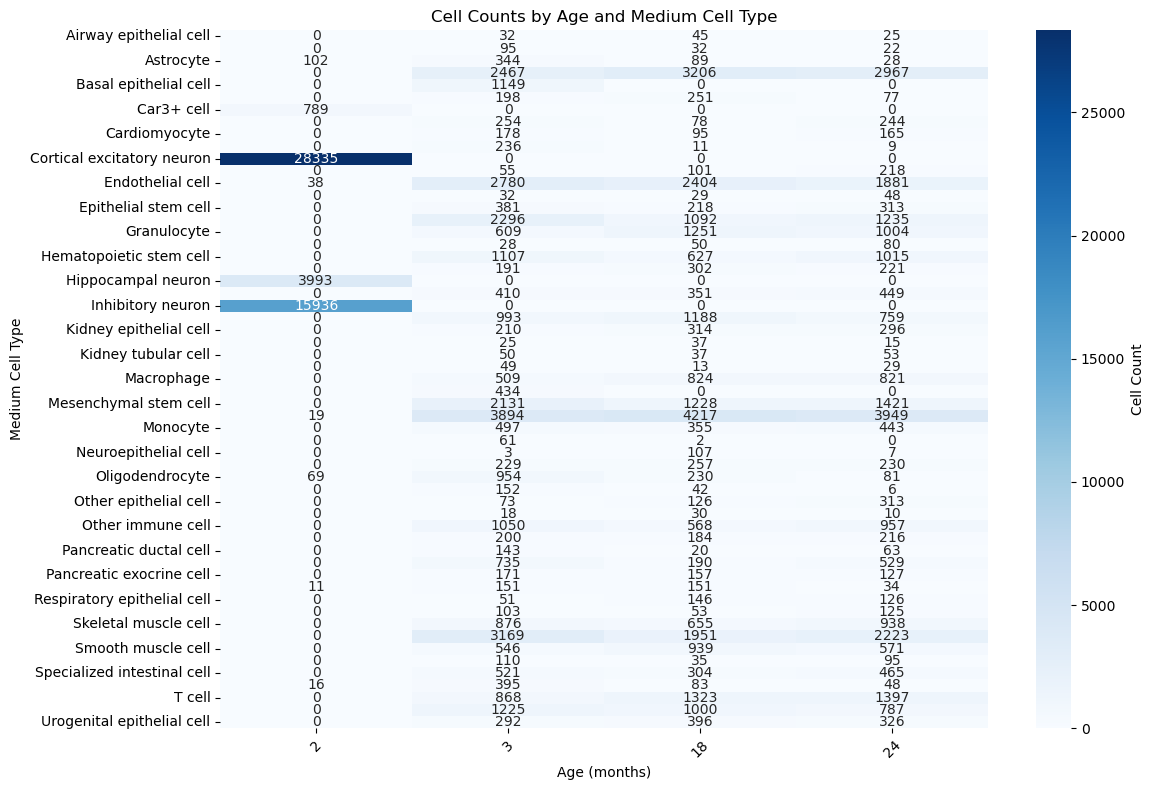

<Figure size 640x480 with 0 Axes>

In [9]:
# summarize cell type versus age numeric heatmap 
# add code here 
# Simple heatmap of medium_cell_type vs age_numeric
print("Creating simple age vs cell type heatmap...")

# Create crosstab for heatmap
heatmap_data = pd.crosstab(
    splice_adata.obs['medium_cell_type'], 
    splice_adata.obs['age_numeric']
).fillna(0)

print(f"Data shape: {heatmap_data.shape}")
print(f"Age range: {splice_adata.obs['age_numeric'].min()} - {splice_adata.obs['age_numeric'].max()} months")

# Create simple heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, 
            annot=True, 
            fmt='g', 
            cmap='Blues',
            cbar_kws={'label': 'Cell Count'})
plt.title('Cell Counts by Age and Medium Cell Type')
plt.xlabel('Age (months)')
plt.ylabel('Medium Cell Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Save the plot
plt.savefig(f"{OUTPUT_DIR}/simple_age_vs_celltype_heatmap.pdf", bbox_inches='tight')

In [10]:
splice_adata

AnnData object with n_obs × n_vars = 137893 × 35197
    obs: 'cell_id_index', 'age', 'cell_ontology_class', 'donor_id', 'sex', 'subtissue', 'tissue', 'dataset', 'cell_name', 'cell_id', 'cell_clean', 'specific_cell_type', 'broad_cell_type', 'medium_cell_type', 'seqtech', 'library_size', 'total_junction_reads', 'annotated_junction_reads', 'unannotated_junction_reads', 'n_detected_annotated_junctions', 'n_detected_unannotated_junctions', 'AgingScore_unweighted', 'AgingScore_pos', 'AgingScore_neg', 'nuclear_ratio_log_norm', 'age_numeric', 'age_group', 'perplexity', 'total_counts', 'nuclear_class_log_norm', 'nuclear_score_log_norm', 'SP_1', 'SP_2', 'SP_3', 'SP_4', 'SP_5', 'SP_6', 'SP_7', 'SP_8', 'SP_9', 'SP_10', 'SP_11', 'SP_12', 'SP_13', 'SP_14', 'SP_15', 'SP_16', 'SP_17', 'SP_18', 'SP_19', 'SP_20'
    var: 'junction_id', 'event_id', 'splice_motif', 'annotation_status', 'gene_name', 'gene_id', 'num_junctions', 'position_off_5_prime', 'position_off_3_prime', 'CountJuncs', 'n_cells_detected'

In [11]:
# assert ge_adata.obs_names == splice_adata.obs_names for all cells 
all(ge_adata.obs_names == splice_adata.obs_names)

True

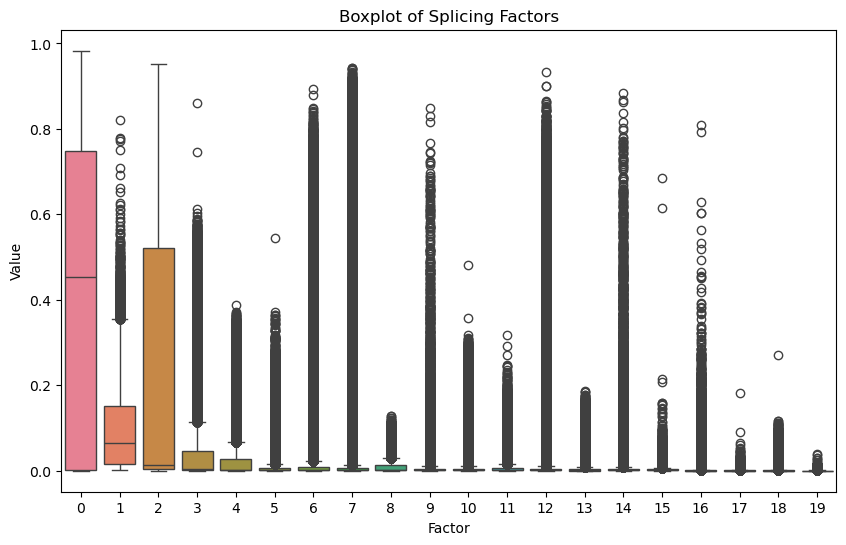

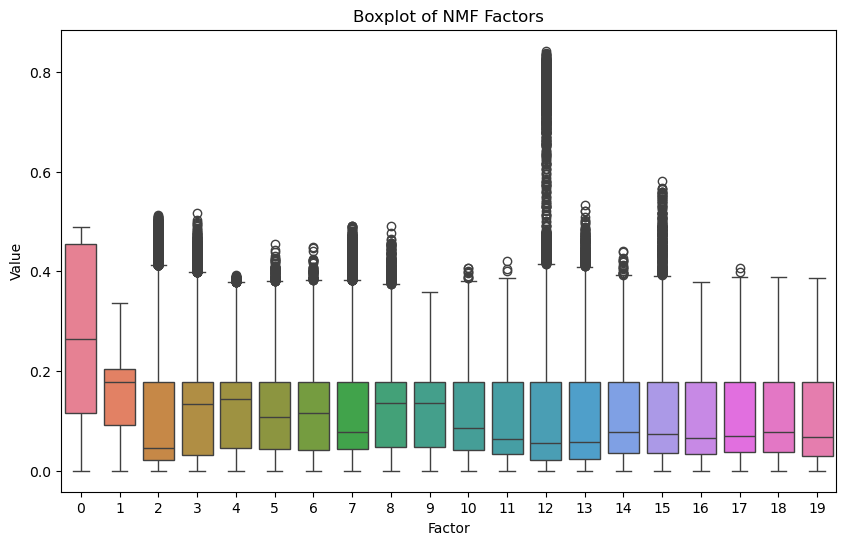

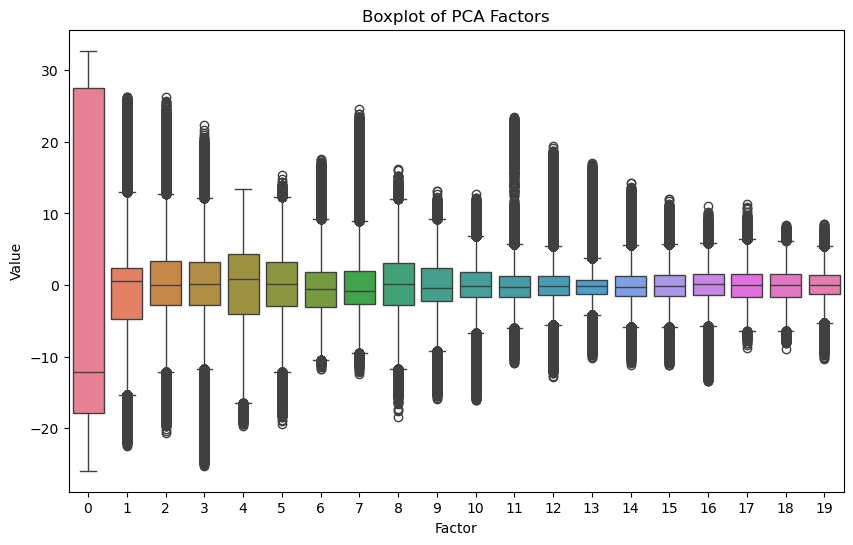

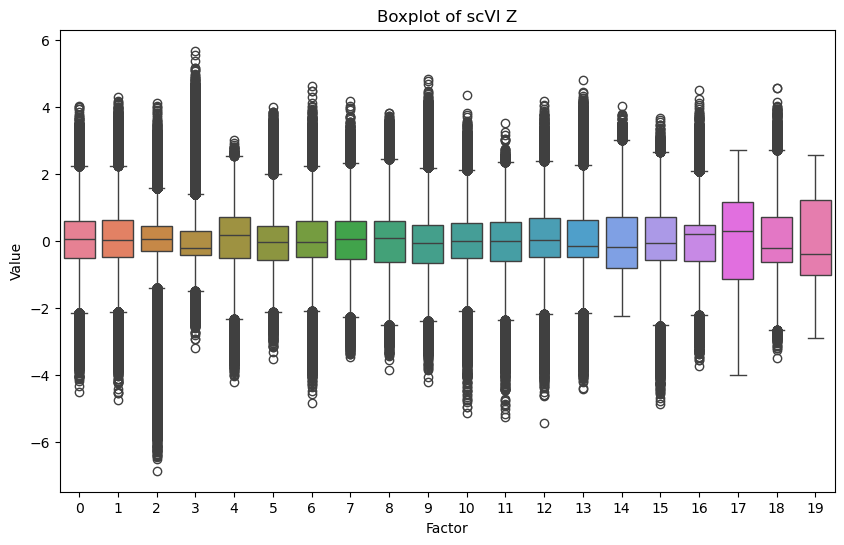

In [12]:
# Extract features (cells are in same order)
dirichlet_feat = splice_adata.obsm["X_PHI"]  # Splicing features (K=20)
scvi_feat = ge_adata.obsm["X_scVI_linear"]   # Gene expression features
nmf_feat = ge_adata.obsm["X_nmf_standard_mb"]
pca_feat = ge_adata.obsm["X_pca"]

# Plot boxplots of dirichlet_feat, one box per factor 
plt.figure(figsize=(10, 6))
sns.boxplot(data=dirichlet_feat)
plt.title('Boxplot of Splicing Factors')
plt.xlabel('Factor')
plt.ylabel('Value')
plt.show()

# Plot boxplots of nmf_feat, one box per factor 
plt.figure(figsize=(10, 6))
sns.boxplot(data=nmf_feat)
plt.title('Boxplot of NMF Factors')
plt.xlabel('Factor')
plt.ylabel('Value')
plt.show()

# Plot boxplots of pca_feat, one box per factor 
plt.figure(figsize=(10, 6))
sns.boxplot(data=pca_feat)
plt.title('Boxplot of PCA Factors')
plt.xlabel('Factor')
plt.ylabel('Value')
plt.show()

# Plot boxplots of dirichlet_feat, one box per factor 
plt.figure(figsize=(10, 6))
sns.boxplot(data=scvi_feat)
plt.title('Boxplot of scVI Z')
plt.xlabel('Factor')
plt.ylabel('Value')
plt.show()

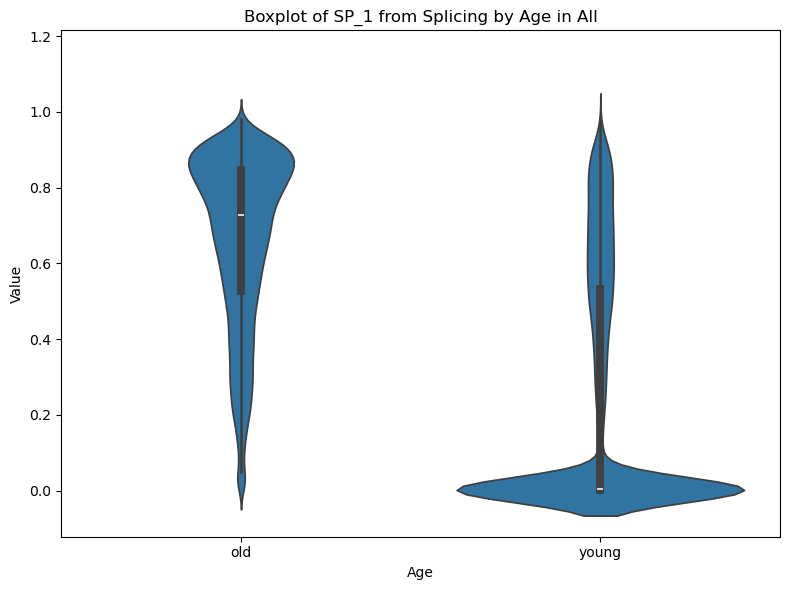

In [14]:
sp = "SP_1"
tissue = "All"
#plot_data = splice_adata.obs[splice_adata.obs["tissue"] == tissue]
plot_data = splice_adata.obs

# Create the boxenplot
plt.figure(figsize=(8, 6))
sns.violinplot(x="age_group", y=sp, data=plot_data)
plt.title(f'Boxplot of {sp} from Splicing by Age in {tissue}')
plt.xlabel('Age')
plt.ylabel('Value')

# Get the unique ages and their order in the plot
unique_ages = sorted(splice_adata.obs["age_numeric"].unique())

# Adjust y-axis to make room for text
plt.ylim(plt.ylim()[0], plt.ylim()[1] * 1.1)

plt.tight_layout()
plt.show()

## Summarize top GSEA pathway per NMF, PCA and scVI dimension

In [20]:
# go through every column in NMF, PCA and scVI and report top positive pathway for each column  
NMF_pathways = {}
PCA_pathways = {}
scVI_pathways = {}

for col in GSEA_NMF_nes.columns:
    # Skip very first column    
    if col == "Unnamed: 0":
        continue
    # sort by ES in column descending order, if no pathways with ES >- report no pathway 
    sorted_es = GSEA_NMF_nes.sort_values(by=col, ascending=False)
    if sorted_es[col].iloc[0] < 0:
        print("No pathways with ES > 0")
        NMF_pathways[col] = "NoPathways"
    else:
        # Join the top 3 pathways into a single string
        NMF_pathways[col] = ', '.join(sorted_es.head(2)["Unnamed: 0"].values)

for col in GSEA_PCA_nes.columns:
    # Skip very first column    
    if col == "Unnamed: 0":
        continue
    sorted_es = GSEA_PCA_nes.sort_values(by=col, ascending=False)
    if sorted_es[col].iloc[0] < 0:
        print("No pathways with ES > 0")
        PCA_pathways[col] = "NoPathways"
    else:
        # Join the top 3 pathways into a single string
        PCA_pathways[col] = ', '.join(sorted_es.head(2)["Unnamed: 0"].values)

for col in GSEA_scVI_nes.columns:
    # Skip very first column    
    if col == "Unnamed: 0":
        continue
    sorted_es = GSEA_scVI_nes.sort_values(by=col, ascending=False)
    if sorted_es[col].iloc[0] < 0:
        print("No pathways with ES > 0")
        scVI_pathways[col] = "NoPathways"
    else:
        # Join the top 3 pathways into a single string
        scVI_pathways[col] = ', '.join(sorted_es.head(2)["Unnamed: 0"].values)

# report dataframe with NMF_pathways
# column 1 = NMF and column 2 is pathway 
NMF_pathways_nes_df = pd.DataFrame(NMF_pathways, index=["pathway"]).T
NMF_pathways_nes_df["method"] = "NMF"
NMF_pathways_nes_df["factor"] = NMF_pathways_nes_df.index
PCA_pathways_nes_df = pd.DataFrame(PCA_pathways, index=["pathway"]).T
PCA_pathways_nes_df["method"] = "PCA"
PCA_pathways_nes_df["factor"] = PCA_pathways_nes_df.index
scVI_pathways_nes_df = pd.DataFrame(scVI_pathways, index=["pathway"]).T
scVI_pathways_nes_df["method"] = "scVI"
scVI_pathways_nes_df["factor"] = scVI_pathways_nes_df.index

## Compare silouette scores and classification of broad and medium cell types across NMF, PCA and scVI low dim space 

In [ ]:
def run_simple_tissue_ridge(splice_adata, ge_adata, covariate="tissue", 
                            alphas=np.logspace(-2, 3, 20)):
    """
    Simple ridge regression by tissue - fit on all data, get single R².
    Much cleaner than problematic CV approach.
    """
    # Extract features
    assert all(splice_adata.obs_names == ge_adata.obs_names)
    
    dirichlet_data = splice_adata.obsm["X_PHI"]
    scvi_data = ge_adata.obsm["X_scVI_linear"] 
    age = splice_adata.obs['age_numeric'].values
    
    results = {}
    
    for tissue in tqdm(splice_adata.obs[covariate].unique()):
        mask = (splice_adata.obs[covariate] == tissue).values
        if mask.sum() < 100 or len(np.unique(age[mask])) == 1:
            continue
            
        # Get tissue-specific data
        X_sp = StandardScaler().fit_transform(dirichlet_data[mask])
        X_sc = StandardScaler().fit_transform(scvi_data[mask])
        X_comb = np.hstack([X_sp, X_sc])
        y = age[mask]
        
        # Fit models with cross-validated alpha selection
        ridge_sp = RidgeCV(alphas=alphas, cv=5).fit(X_sp, y)
        ridge_sc = RidgeCV(alphas=alphas, cv=5).fit(X_sc, y) 
        ridge_comb = RidgeCV(alphas=alphas, cv=5).fit(X_comb, y)
        
        # Get R² on full data (much more stable!)
        r2_sp = ridge_sp.score(X_sp, y)
        r2_sc = ridge_sc.score(X_sc, y)
        r2_comb = ridge_comb.score(X_comb, y)
        
        # F-test for significance
        n = len(y)
        rss_sp = np.sum((y - ridge_sp.predict(X_sp))**2)
        rss_sc = np.sum((y - ridge_sc.predict(X_sc))**2)
        rss_comb = np.sum((y - ridge_comb.predict(X_comb))**2)
        
        # Test combined vs individual models
        f_vs_sp = ((rss_sp - rss_comb) / X_sc.shape[1]) / (rss_comb / (n - X_sp.shape[1] - X_sc.shape[1] - 1))
        p_vs_sp = 1 - stats.f.cdf(f_vs_sp, X_sc.shape[1], n - X_sp.shape[1] - X_sc.shape[1] - 1)
        
        f_vs_sc = ((rss_sc - rss_comb) / X_sp.shape[1]) / (rss_comb / (n - X_sp.shape[1] - X_sc.shape[1] - 1))
        p_vs_sc = 1 - stats.f.cdf(f_vs_sc, X_sp.shape[1], n - X_sp.shape[1] - X_sc.shape[1] - 1)
        
        results[tissue] = {
            'n_cells': mask.sum(),
            'splice_r2': r2_sp,
            'scvi_r2': r2_sc, 
            'combined_r2': r2_comb,
            'p_combined_vs_splice': p_vs_sp,
            'p_combined_vs_scvi': p_vs_sc
        }
    
    return results

# Run the cleaner analysis
results = run_simple_tissue_ridge(splice_adata, ge_adata, covariate="medium_cell_type")

100%|██████████| 57/57 [02:25<00:00,  2.56s/it]


In [67]:
# Create summary DataFrame
summary_data = []
for tissue, res in results.items():
    summary_data.append({
        'tissue': tissue,
        'n_cells': res['n_cells'],
        'LeafletFA_r2': res['splice_r2'],
        'scVI_r2': res['scvi_r2'],
        'LeafletFA_scVI_r2': res['combined_r2'],
        'p_combined_vs_LeafletFA': res['p_combined_vs_splice'],
        'p_combined_vs_scVI': res['p_combined_vs_scvi']
    })

summary_df = pd.DataFrame(summary_data)

# Simple, clean plot
summary_df_sorted = summary_df.sort_values('LeafletFA_r2', ascending=False)
tissues = summary_df_sorted['tissue'].values
models = ['LeafletFA', 'scVI', 'LeafletFA_scVI']

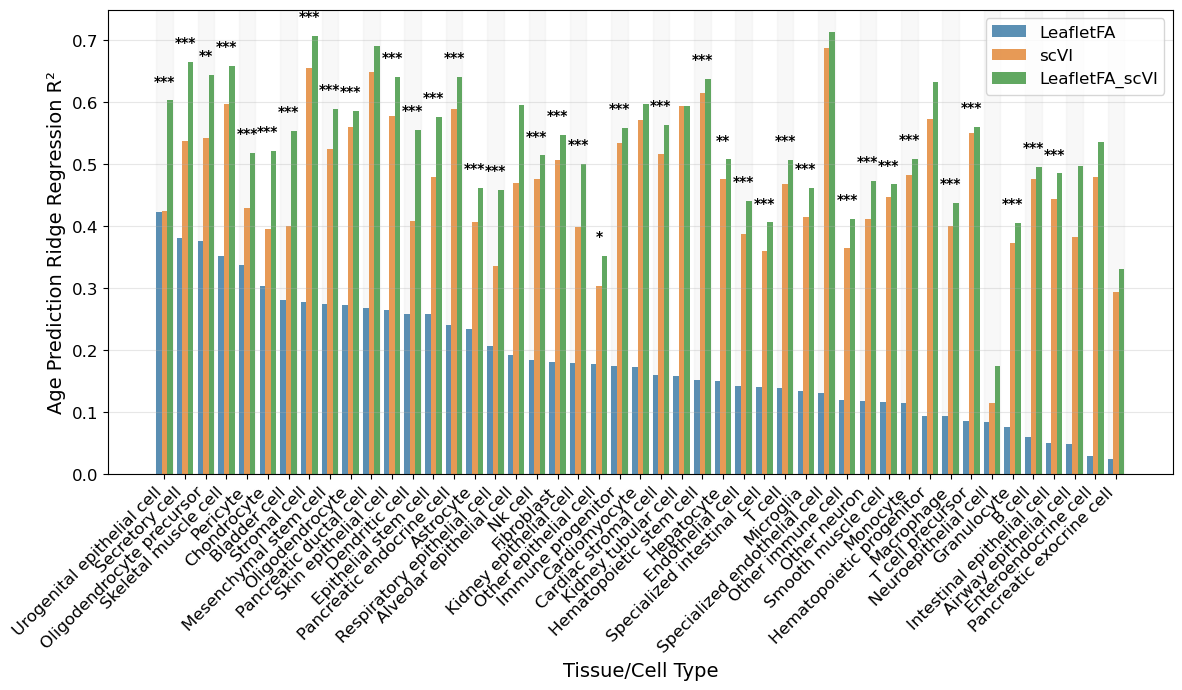

Saved plot to /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/age_prediction_performance.pdf


In [ ]:
import seaborn as sns
from statsmodels.stats.multitest import multipletests

# FDR correction
summary_df_sorted["p_combined_vs_scVI_fdr"] = multipletests(summary_df_sorted["p_combined_vs_scVI"], method="fdr_bh")[1]

# Reshape data for seaborn
plot_data = []
for _, row in summary_df_sorted.iterrows():
    for model in ['LeafletFA', 'scVI', 'LeafletFA_scVI']:
        plot_data.append({
            'tissue': row['tissue'],
            'model': model,
            'r2': row[f'{model}_r2']
        })

plot_df = pd.DataFrame(plot_data)

# Create plot
fig, ax = plt.subplots(figsize=(12, 7))

# Seaborn barplot
sns.barplot(data=plot_df, x='tissue', y='r2', hue='model', ax=ax, alpha=0.8)

# Add alternating backgrounds
for i in range(len(summary_df_sorted)):
    if i % 2 == 0:
        ax.axvspan(i - 0.4, i + 0.4, alpha=0.3, color='lightgray', zorder=0)

# Add significance asterisks on combined bars
for i, (_, row) in enumerate(summary_df_sorted.iterrows()):
    p_val = row['p_combined_vs_scVI_fdr']
    sig_text = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else ""
    
    if sig_text:
        combined_r2 = row['LeafletFA_scVI_r2']
        ax.text(i, combined_r2 + 0.02, sig_text, ha='center', va='bottom', 
               fontweight='bold', fontsize=10)

ax.set_xlabel('Tissue/Cell Type', fontsize=14)
ax.set_ylabel('Age Prediction Ridge Regression R²', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
ax.legend(fontsize=12)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()

# Save as PDF
plt.savefig(f'{OUTPUT_DIR}/age_prediction_performance.pdf', dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved plot to {OUTPUT_DIR}/age_prediction_performance.pdf")

## Make heatmap of LeafletFA factors versus GSEA for NMF or scVI or PCA loadings 

In [91]:
# Enhanced scVI-LeafletFA Correlation Analysis with GSEA Pathways
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests

# Configuration parameters
top_k_genes = 5
fdr_thresh = 0.05
rho_thresh = 0.2

# Extract data matrices
X_PHI = splice_adata.obsm["X_PHI"]  # LeafletFA splicing factors
X_scVI = ge_adata.obsm["X_scVI_linear"]  # scVI latent factors
scvi_gene_loadings = ge_adata.varm["scVI_linear_gene_loadings"]  # Gene loadings matrix
gene_names = ge_adata.var["gene_name"].values

# Matrix dimensions
n_scvi_factors = X_scVI.shape[1]  # Number of scVI factors (Z_0 to Z_19)
n_splicing_factors = X_PHI.shape[1]  # Number of splicing programs
print(f"scVI factors: {n_scvi_factors}, Splicing factors: {n_splicing_factors}")

# Create factor labels
scvi_factor_names = [f"Z_{i+1}" for i in range(n_scvi_factors)]
splicing_factor_names = [f"SP_{i+1}" for i in range(n_splicing_factors)]

# Load GSEA results (assuming you have this data structure)
# This should be a DataFrame or dictionary containing GSEA results for each factor
# Format: {factor_name: [{'Term': pathway_name, 'NES': score, 'FDR q-val': fdr, ...}, ...]}
def get_top_unique_positive_pathway_or_genes(factor_name, factor_idx, gsea_df, gene_loadings, gene_names, used_pathways, top_k=5):
    """
    Get the top unique positively enriched pathway for a factor from GSEA DataFrame, or top genes if no pathway available.
    Prioritizes positive NES values and ensures pathway uniqueness across factors.
    """
    # Filter GSEA results for this specific factor
    factor_results = gsea_df[gsea_df['Factor'] == factor_name].copy()
    
    if len(factor_results) > 0:
        # First, try to find positive pathways (NES > 0) that are significant and not already used
        positive_results = factor_results[
            (factor_results['NES'] > 0) & 
            (factor_results['FDR q-val'] < 0.05) &
            (~factor_results['Term'].isin(used_pathways))
        ]
        
        if len(positive_results) > 0:
            # Get the best positive pathway (lowest FDR among positive)
            best_pathway = positive_results.loc[positive_results['FDR q-val'].idxmin()]
        else:
            # If no positive unique pathways, try any significant unused pathway
            unused_results = factor_results[
                (factor_results['FDR q-val'] < 0.05) &
                (~factor_results['Term'].isin(used_pathways))
            ]
            
            if len(unused_results) > 0:
                best_pathway = unused_results.loc[unused_results['FDR q-val'].idxmin()]
            else:
                # Last resort: just get the best pathway regardless of uniqueness
                best_pathway = factor_results.loc[factor_results['FDR q-val'].idxmin()]
        
        # Add this pathway to used pathways
        used_pathways.add(best_pathway['Term'])
        
        # Extract pathway name (remove GO ID if present)
        pathway_name = best_pathway['Term']
        if '(GO:' in pathway_name:
            pathway_name = pathway_name.split('(GO:')[0].strip()
        
        # Truncate if too long
        if len(pathway_name) > 40:
            pathway_name = pathway_name[:37] + "..."
            
        return f"{pathway_name} (NES={best_pathway['NES']:.2f})"
    else:
        # Fall back to top genes based on loadings
        factor_loadings = gene_loadings.iloc[:, factor_idx].values
        top_gene_indices = np.argsort(-np.abs(factor_loadings))[:top_k]
        top_genes = gene_names[top_gene_indices]
        return f"Top genes: {', '.join(top_genes)}"

# Load GSEA results (assuming GSEA_scVI_full is your DataFrame)
gsea_results = GSEA_scVI_full

# Create labels with unique positive pathways or top genes
used_pathways = set()  # Track used pathways to ensure uniqueness
scvi_labels = []
for i, factor_name in enumerate(scvi_factor_names):
    label_info = get_top_unique_positive_pathway_or_genes(
        factor_name, i, gsea_results, scvi_gene_loadings, gene_names, used_pathways, top_k_genes
    )
    scvi_labels.append(f"{factor_name}: {label_info}")

print("scVI factor labels created (prioritizing positive, unique pathways):")
for label in scvi_labels[:5]:  # Show first 5 as example
    print(f"  {label}")

# Compute correlation matrix between scVI factors and splicing factors
print("Computing correlations...")
corr_matrix = np.zeros((n_scvi_factors, n_splicing_factors))
pval_matrix = np.zeros((n_scvi_factors, n_splicing_factors))

for i in range(n_scvi_factors):
    scvi_activity = X_scVI[:, i]
    for j in range(n_splicing_factors):
        splicing_activity = X_PHI[:, j]
        rho, pval = spearmanr(scvi_activity, splicing_activity)
        corr_matrix[i, j] = rho
        pval_matrix[i, j] = pval

# FDR correction
print("Applying FDR correction...")
_, pvals_fdr_flat, _, _ = multipletests(pval_matrix.flatten(), method='fdr_bh')
fdr_matrix = pvals_fdr_flat.reshape(pval_matrix.shape)

# Create significance annotations
annot_matrix = np.where(
    (fdr_matrix < fdr_thresh) & (np.abs(corr_matrix) > rho_thresh),
    "*",
    ""
)

# Convert to DataFrames
corr_df = pd.DataFrame(
    corr_matrix, 
    index=scvi_labels, 
    columns=splicing_factor_names
)
fdr_df = pd.DataFrame(
    fdr_matrix, 
    index=scvi_labels, 
    columns=splicing_factor_names
)

# Save results
print("Saving correlation matrices...")
corr_df.to_csv(os.path.join(OUTPUT_DIR, "scVI_leafletFA_correlations.csv"))

# Create enhanced clustermap
print("Creating visualization...")
plt.figure(figsize=(8, 6))

g = sns.clustermap(
    corr_df,
    cmap="PRGn",  # Red-blue colormap, more intuitive for correlations
    center=0,
    linewidths=0.3,
    linecolor="white",
    xticklabels=True,
    yticklabels=True,
    annot=annot_matrix,
    fmt='',
    annot_kws={'size': 8, 'color': 'black', 'weight': 'bold'},
    figsize=(5, 6),  # Increased width to accommodate longer labels
    cbar_kws={'label': 'Spearman Correlation', 'shrink': 0.8},
    col_cluster=False,  # Don't cluster columns (LeafletFA factors) to preserve SP_1, SP_2... order
    row_cluster=True   # Still cluster rows (scVI factors) to group similar patterns
)

# Enhance plot aesthetics
g.ax_heatmap.set_xlabel("LeafletFA Splicing Programs", fontsize=14, fontweight='bold')
g.ax_heatmap.set_ylabel("scVI Latent Factors (with Top Pathways/Genes)", fontsize=14, fontweight='bold')

# Adjust tick labels - make them more readable
plt.setp(g.ax_heatmap.get_xticklabels(), rotation=90, fontsize=12)
plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0, fontsize=12)  # Slightly larger for pathway names

# Enhance colorbar
g.cax.tick_params(labelsize=10)
g.cax.set_ylabel("Spearman Correlation", fontsize=12, fontweight='bold')

# Add significance legend with better positioning
legend_text = f"* Significant: FDR < {fdr_thresh}, |ρ| > {rho_thresh}"
g.fig.text(0.02, 0.98, legend_text, fontsize=11, style='italic', 
           verticalalignment='top', bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray", alpha=0.7))

# Save high-quality figure
output_path = os.path.join(OUTPUT_DIR, "scVI_leafletFA_correlation_clustermap.pdf")
g.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f"Saved correlation plot to: {output_path}")

plt.close(g.fig)

# Print summary statistics
print("\n=== Analysis Summary ===")
print(f"Total correlations computed: {n_scvi_factors} × {n_splicing_factors} = {n_scvi_factors * n_splicing_factors}")
significant_correlations = np.sum((fdr_matrix < fdr_thresh) & (np.abs(corr_matrix) > rho_thresh))
print(f"Significant correlations: {significant_correlations}")
print(f"Strongest positive correlation: {np.max(corr_matrix):.3f}")
print(f"Strongest negative correlation: {np.min(corr_matrix):.3f}")

# Display pathway information for each factor (showing positive enrichment priority)
print("\n=== scVI Factor Pathway Annotations (Positive Enrichment Priority) ===")
pathway_summary = []
for i, factor_name in enumerate(scvi_factor_names):
    factor_results = gsea_results[gsea_results['Factor'] == factor_name]
    
    if len(factor_results) > 0:
        # Show positive pathways first, then others
        positive_pathways = factor_results[factor_results['NES'] > 0].nsmallest(2, 'FDR q-val')
        negative_pathways = factor_results[factor_results['NES'] < 0].nsmallest(1, 'FDR q-val')
        
        pathway_info = []
        
        # Add positive pathways first
        for _, pathway in positive_pathways.iterrows():
            pathway_info.append(f"(+) {pathway['Term']} (NES={pathway['NES']:.2f}, FDR={pathway['FDR q-val']:.3f})")
        
        # Add one negative pathway if available
        for _, pathway in negative_pathways.iterrows():
            pathway_info.append(f"(-) {pathway['Term']} (NES={pathway['NES']:.2f}, FDR={pathway['FDR q-val']:.3f})")
        
        pathway_summary.append({
            'Factor': factor_name,
            'Top_Pathways': '; '.join(pathway_info[:3]),  # Limit to top 3
            'Positive_Pathways': len(factor_results[factor_results['NES'] > 0]),
            'Negative_Pathways': len(factor_results[factor_results['NES'] < 0]),
            'Num_Significant': len(factor_results[factor_results['FDR q-val'] < 0.05])
        })
    else:
        # Show top genes instead
        factor_loadings = scvi_gene_loadings.iloc[:, i].values
        top_gene_indices = np.argsort(-np.abs(factor_loadings))[:5]
        top_genes = gene_names[top_gene_indices]
        
        pathway_summary.append({
            'Factor': factor_name,
            'Top_Pathways': f"Top genes: {', '.join(top_genes)}",
            'Positive_Pathways': 0,
            'Negative_Pathways': 0,
            'Num_Significant': 0
        })

pathway_summary_df = pd.DataFrame(pathway_summary)
print(pathway_summary_df.to_string(index=False))

# Save pathway summary
pathway_summary_df.to_csv(os.path.join(OUTPUT_DIR, "scVI_factor_positive_pathway_summary.csv"), index=False)
if significant_correlations > 0:
    print("\n=== Top Significant Correlations ===")
    sig_mask = (fdr_matrix < fdr_thresh) & (np.abs(corr_matrix) > rho_thresh)
    sig_positions = np.where(sig_mask)
    
    correlations_data = []
    for i, j in zip(sig_positions[0], sig_positions[1]):
        correlations_data.append({
            'scVI_Factor': scvi_factor_names[i],
            'Splicing_Program': splicing_factor_names[j],
            'Correlation': corr_matrix[i, j],
            'FDR': fdr_matrix[i, j],
            'Pathway/Genes': scvi_labels[i].split(': ', 1)[1]
        })
    
    sig_corr_df = pd.DataFrame(correlations_data)
    sig_corr_df = sig_corr_df.sort_values('Correlation', key=abs, ascending=False)
    
    print(sig_corr_df.head(10).to_string(index=False))
    
    # Save significant correlations
    sig_corr_df.to_csv(os.path.join(OUTPUT_DIR, "significant_scVI_leafletFA_correlations.csv"), index=False)

print("\nAnalysis complete!")

scVI factors: 20, Splicing factors: 20
scVI factor labels created (prioritizing positive, unique pathways):
  Z_1: cytoplasmic translation (NES=2.05)
  Z_2: SRP-dependent cotranslational protein... (NES=2.14)
  Z_3: nuclear-transcribed mRNA poly(A) tail... (NES=2.72)
  Z_4: cotranslational protein targeting to ... (NES=2.39)
  Z_5: regulation of adaptive immune response (NES=2.13)
Computing correlations...
Applying FDR correction...
Saving correlation matrices...
Creating visualization...
Saved correlation plot to: /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/scVI_leafletFA_correlation_clustermap.pdf

=== Analysis Summary ===
Total correlations computed: 20 × 20 = 400
Significant correlations: 119
Strongest positive correlation: 0.746
Strongest negative correlation: -0.781

=== scVI Factor Pathway Annotations (Positive Enrichment Priority) ===
Factor                           

<Figure size 800x600 with 0 Axes>

Available categories in medium_cell_type: ['Airway epithelial cell', 'Alveolar epithelial cell', 'Astrocyte', 'B cell', 'Basal epithelial cell', 'Bladder cell', 'Car3+ cell', 'Cardiac stromal cell', 'Cardiomyocyte', 'Chondrocyte', 'Cortical excitatory neuron', 'Dendritic cell', 'Endothelial cell', 'Enteroendocrine cell', 'Epithelial stem cell', 'Fibroblast', 'Granulocyte', 'Hematopoietic progenitor', 'Hematopoietic stem cell', 'Hepatocyte', 'Hippocampal neuron', 'Immune progenitor', 'Inhibitory neuron', 'Intestinal epithelial cell', 'Kidney epithelial cell', 'Kidney glomerular cell', 'Kidney tubular cell', 'Lymphatic endothelial cell', 'Macrophage', 'Mammary epithelial cell', 'Mesenchymal stem cell', 'Microglia', 'Monocyte', 'Neural stem cell', 'Neuroepithelial cell', 'Nk cell', 'Oligodendrocyte', 'Oligodendrocyte precursor', 'Other epithelial cell', 'Other glial cell', 'Other immune cell', 'Other neuron', 'Pancreatic ductal cell', 'Pancreatic endocrine cell', 'Pancreatic exocrine cell

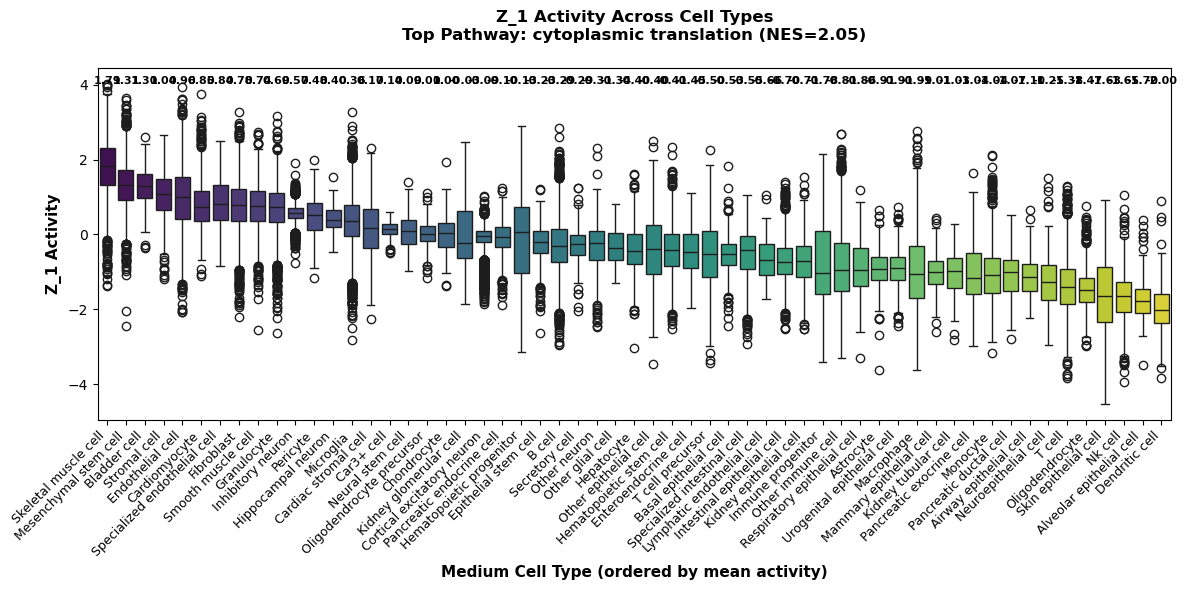

Creating plot 2/20: Z_2


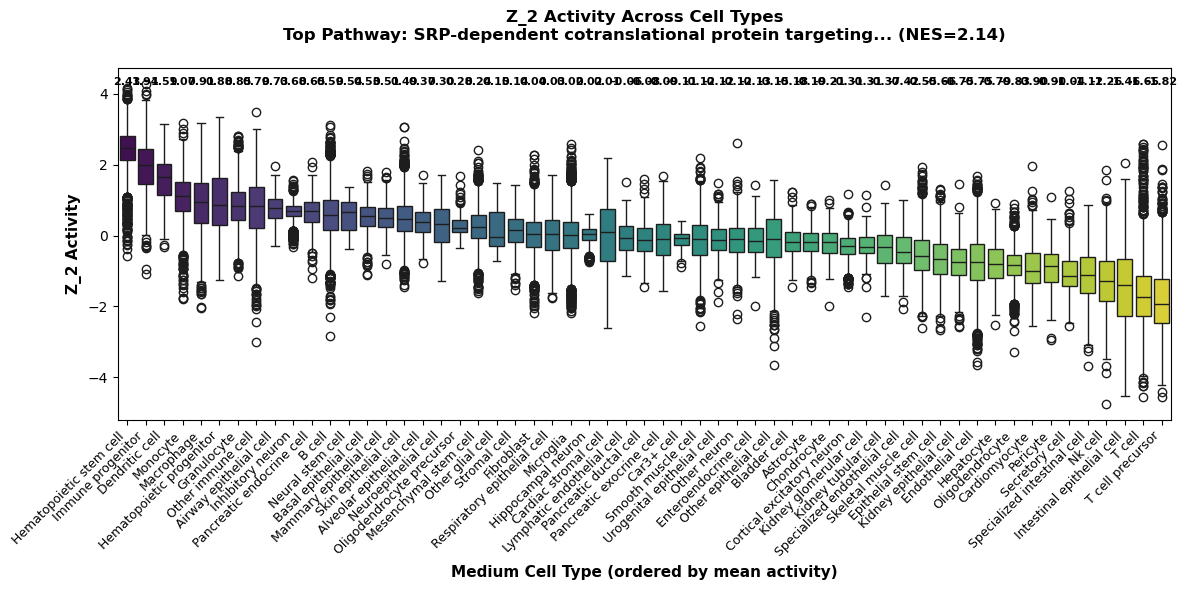

Creating plot 3/20: Z_3


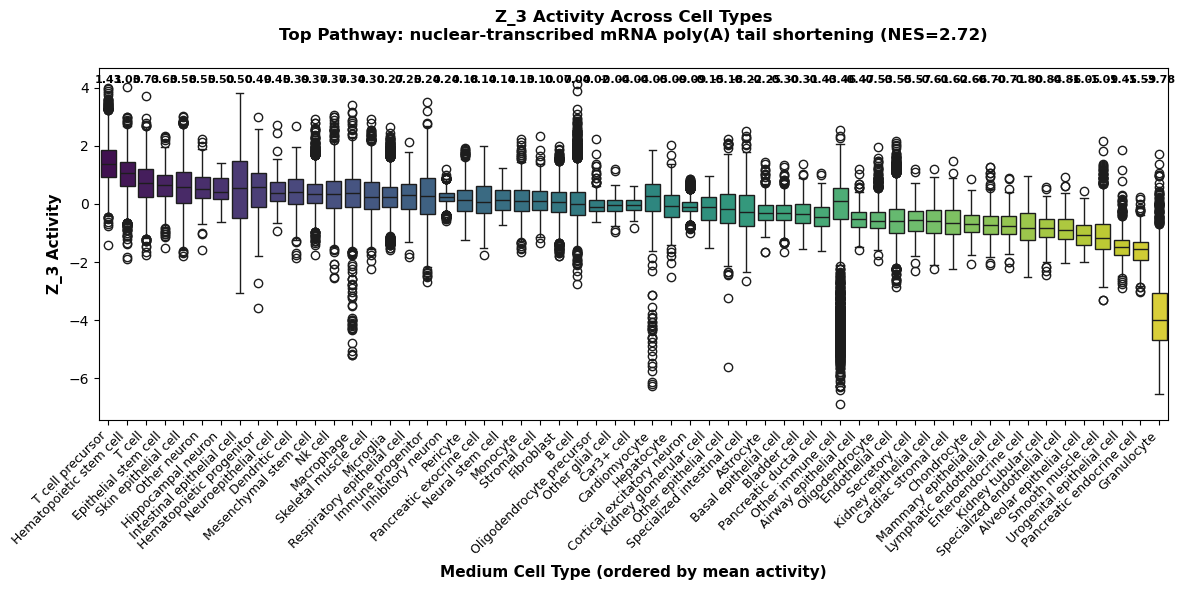

Creating plot 4/20: Z_4


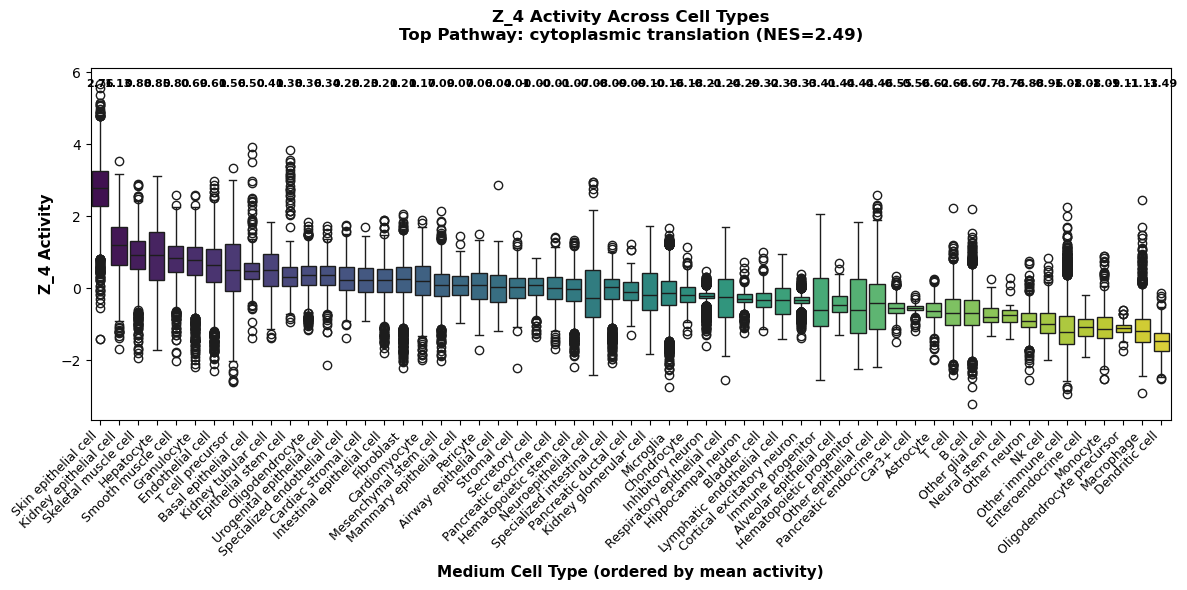

Creating plot 5/20: Z_5


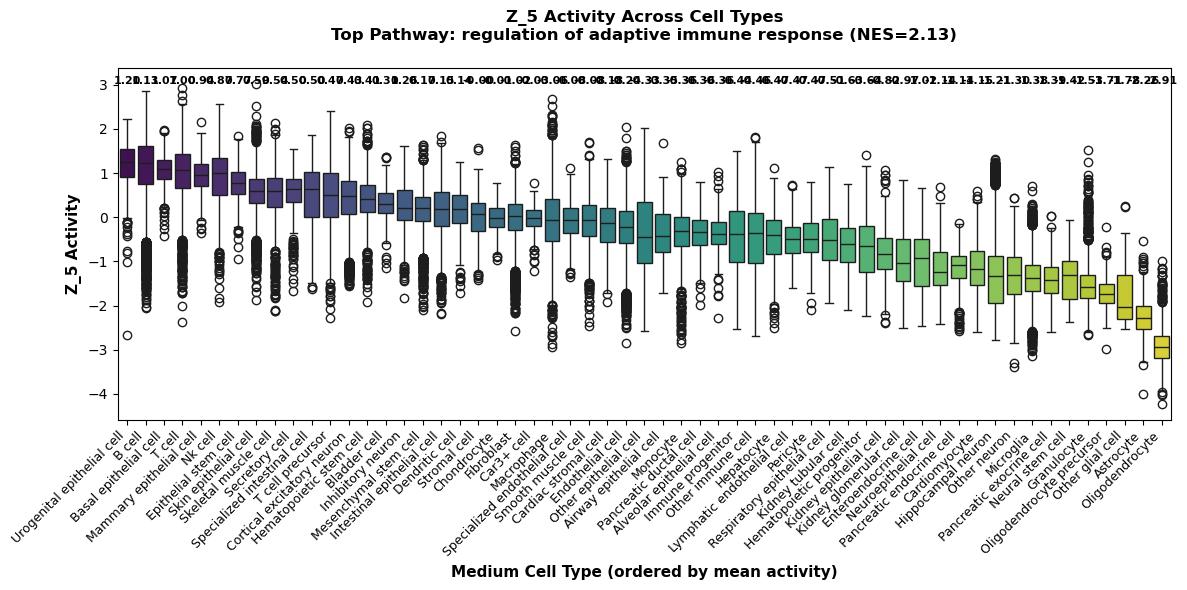

Creating plot 6/20: Z_6


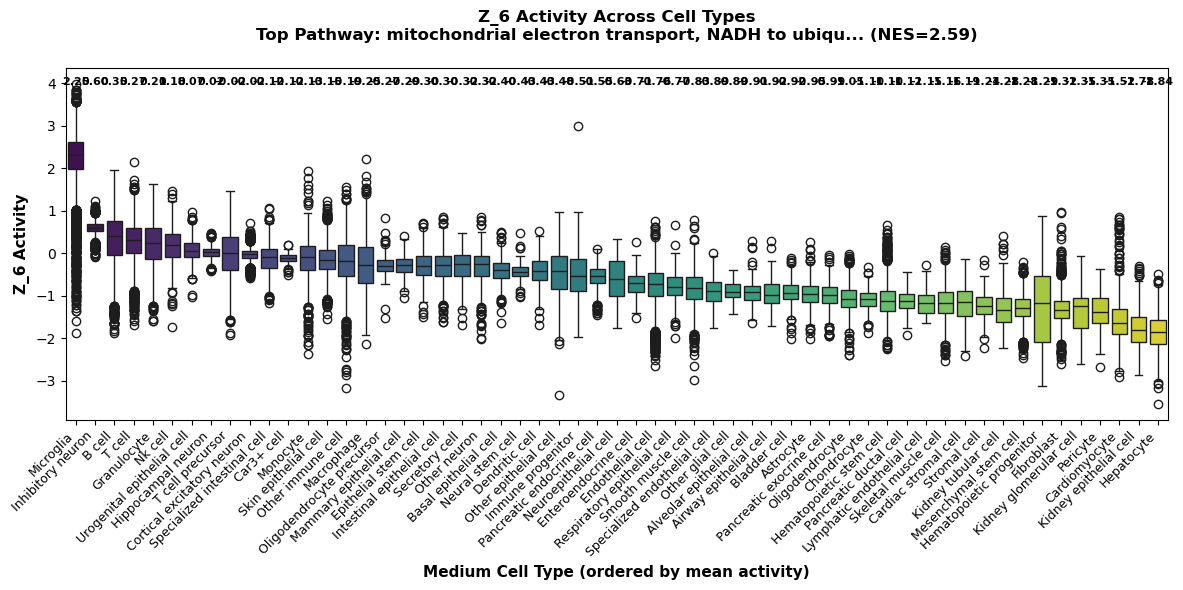

Creating plot 7/20: Z_7


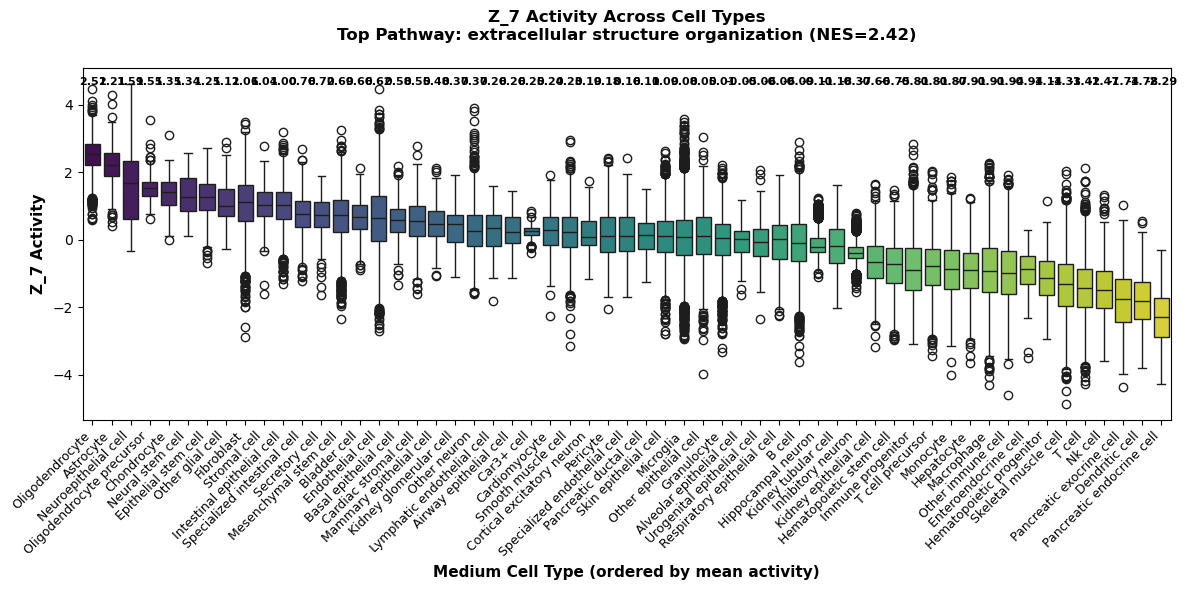

Creating plot 8/20: Z_8


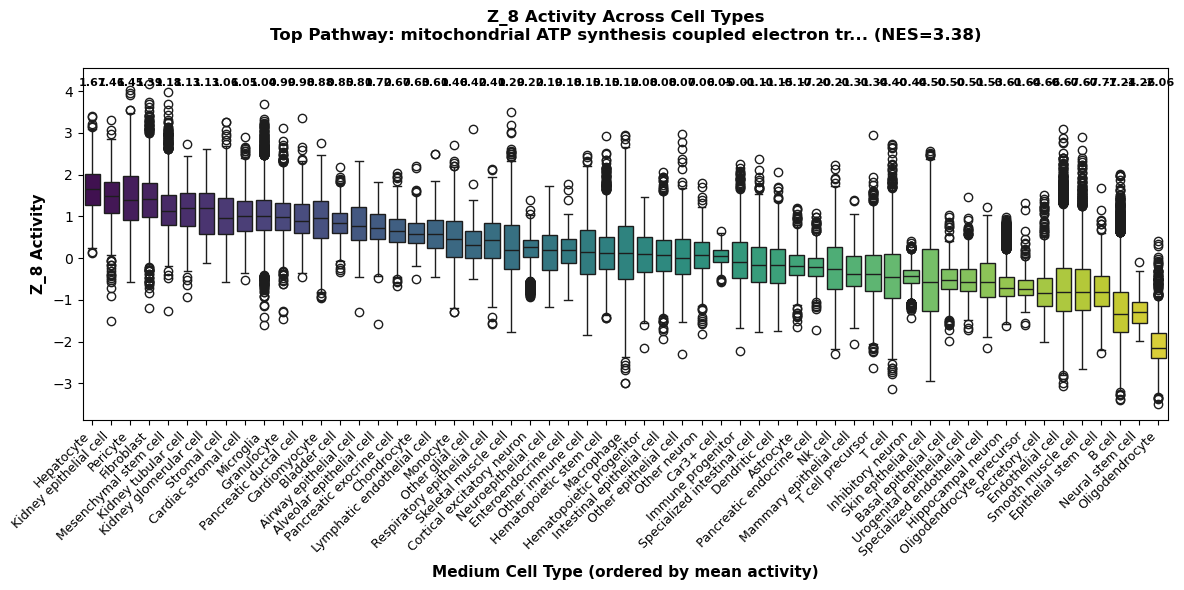

Creating plot 9/20: Z_9


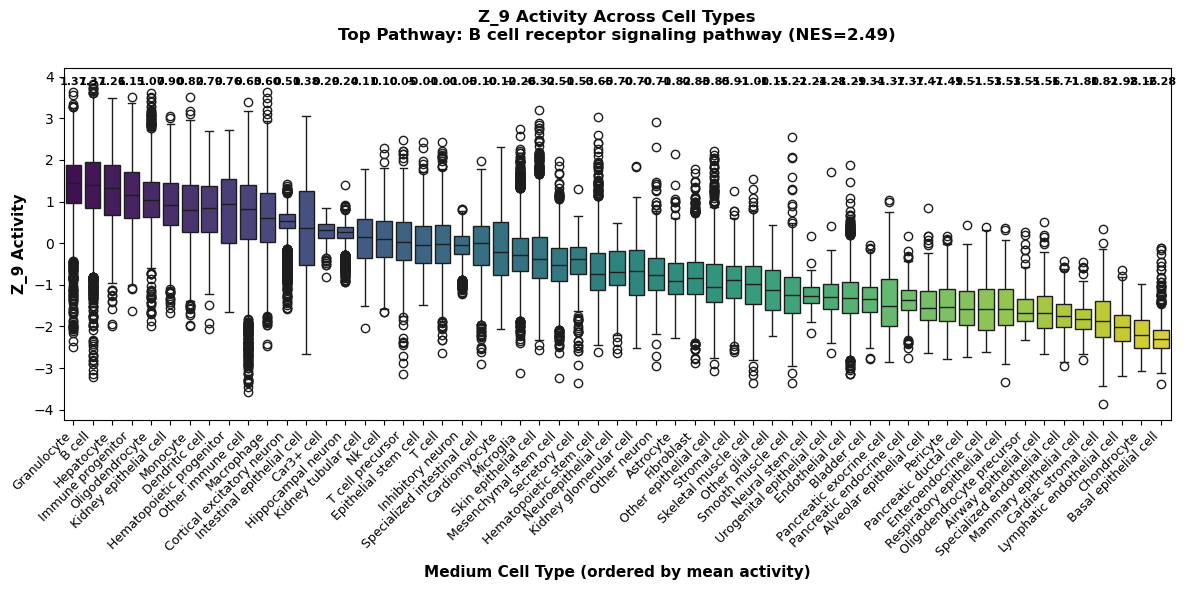

Creating plot 10/20: Z_10


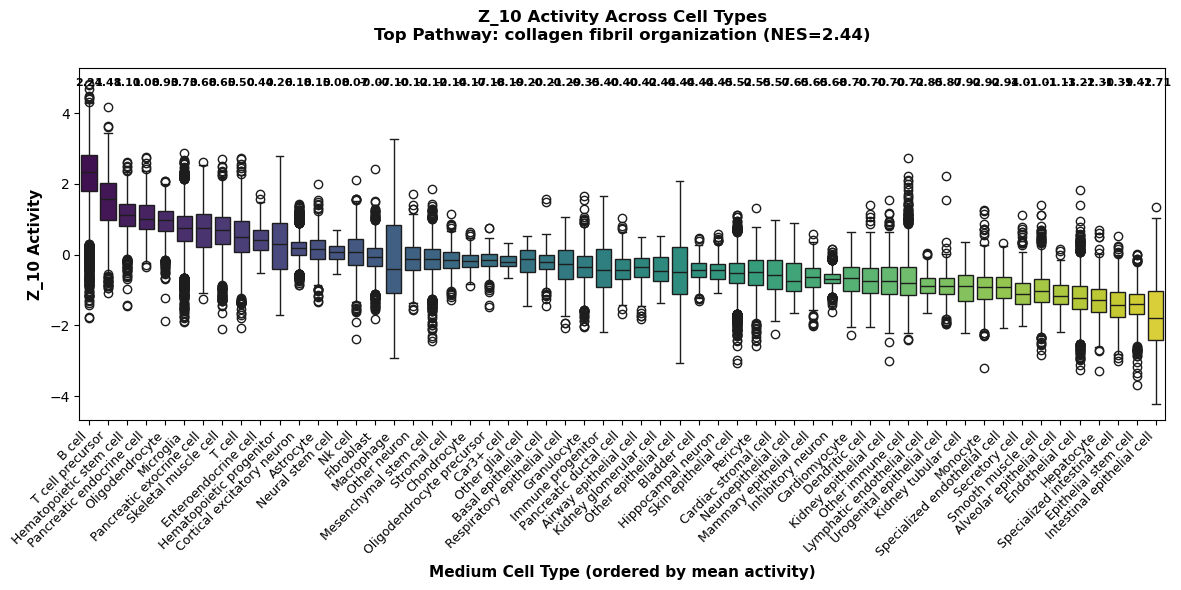

Creating plot 11/20: Z_11


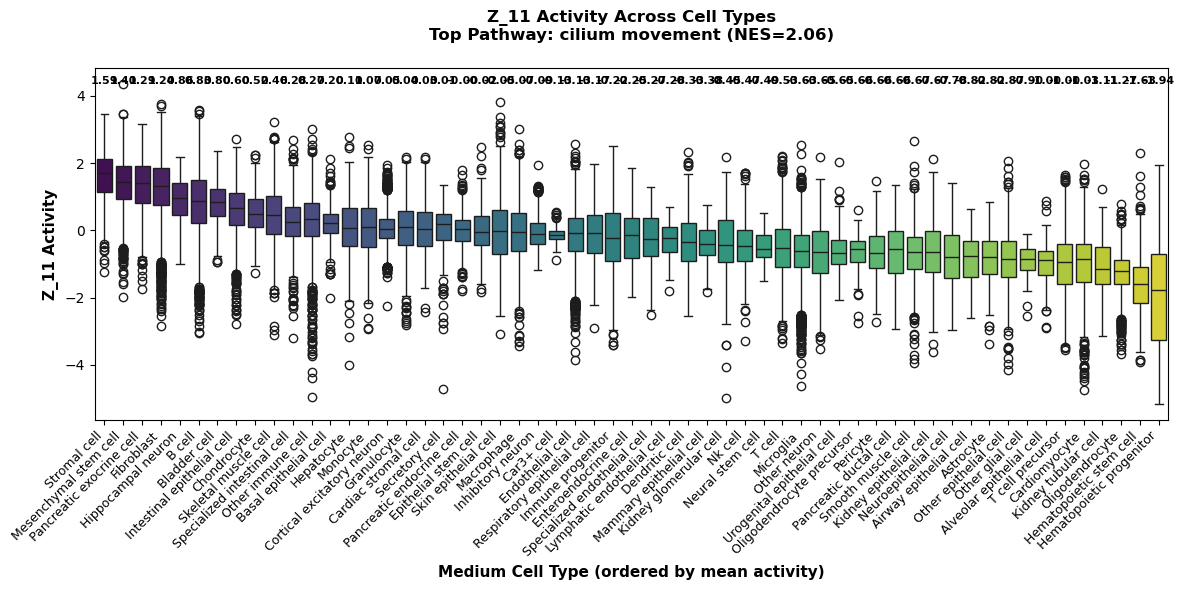

Creating plot 12/20: Z_12


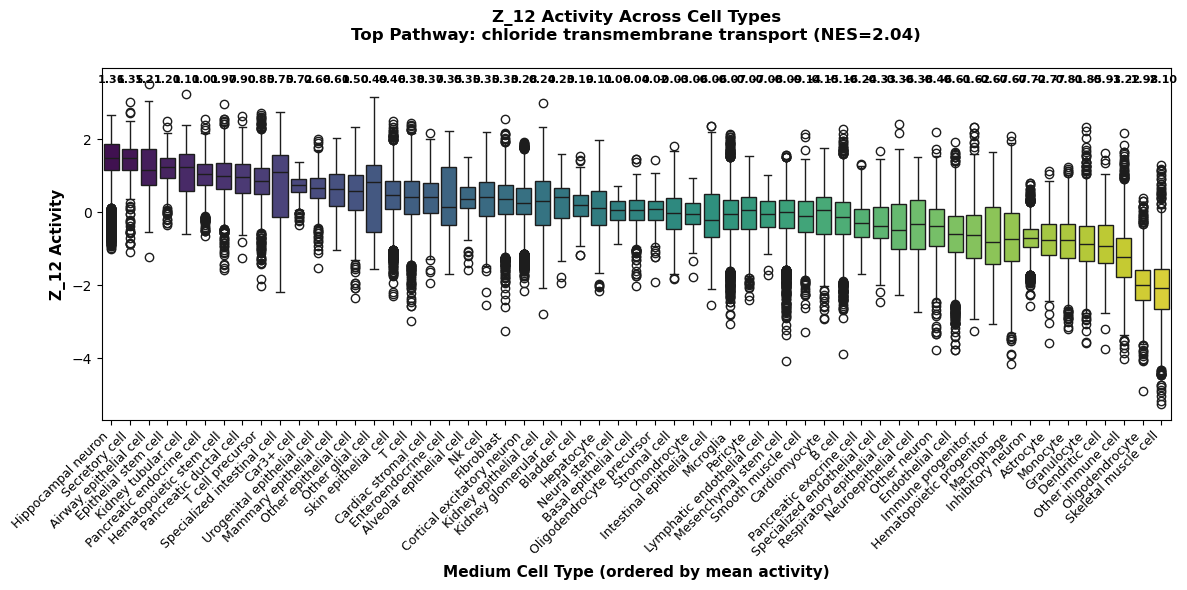

Creating plot 13/20: Z_13


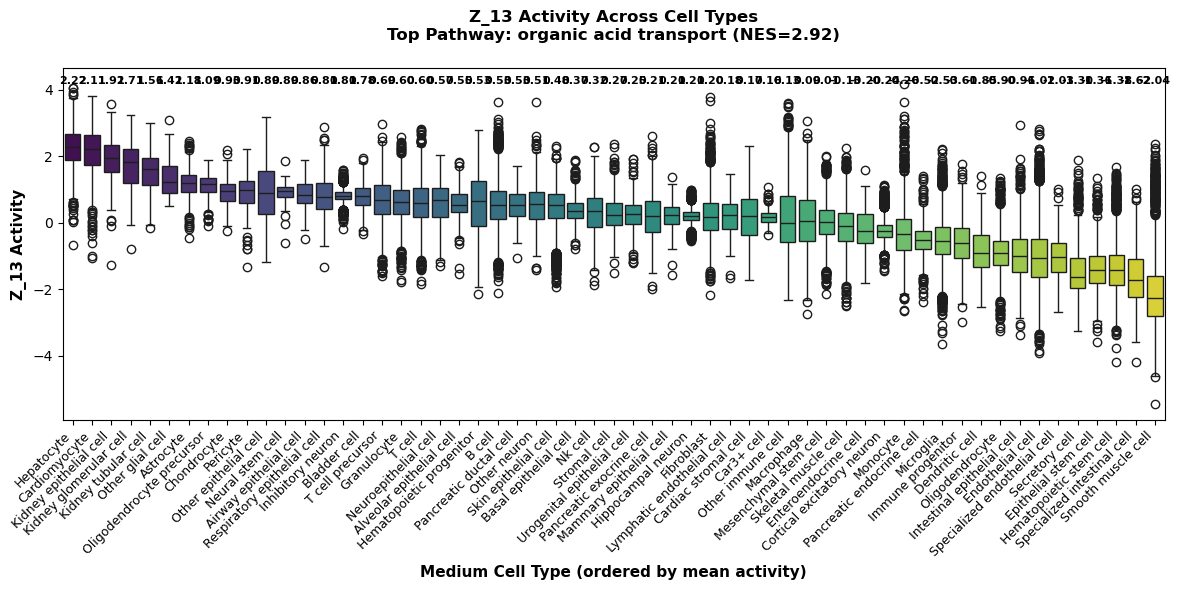

Creating plot 14/20: Z_14


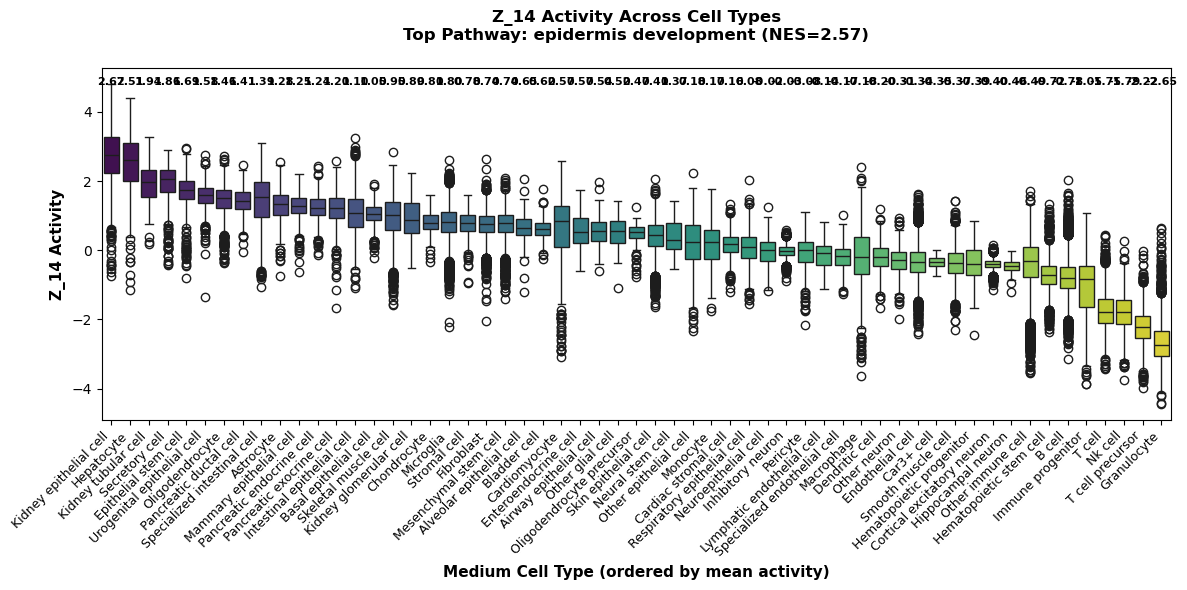

Creating plot 15/20: Z_15


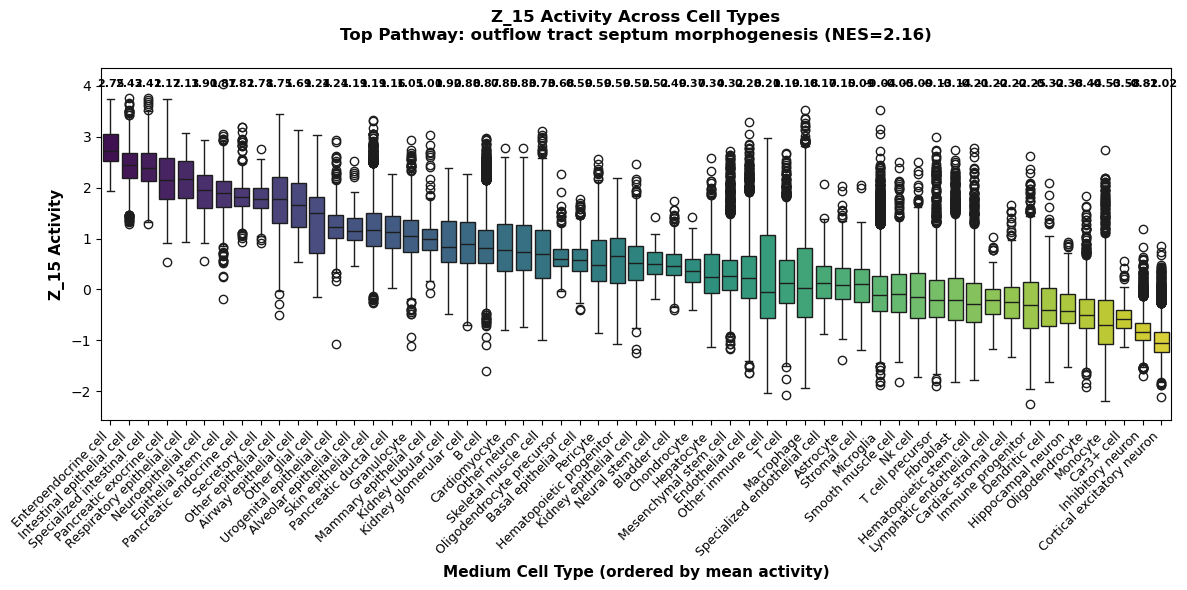

Creating plot 16/20: Z_16


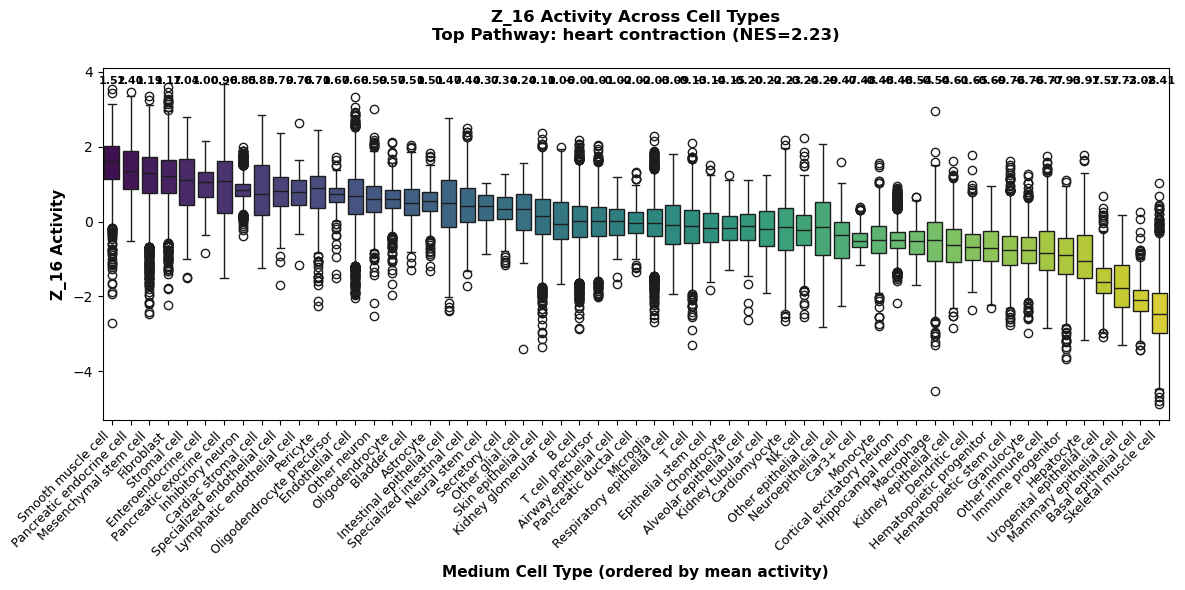

Creating plot 17/20: Z_17


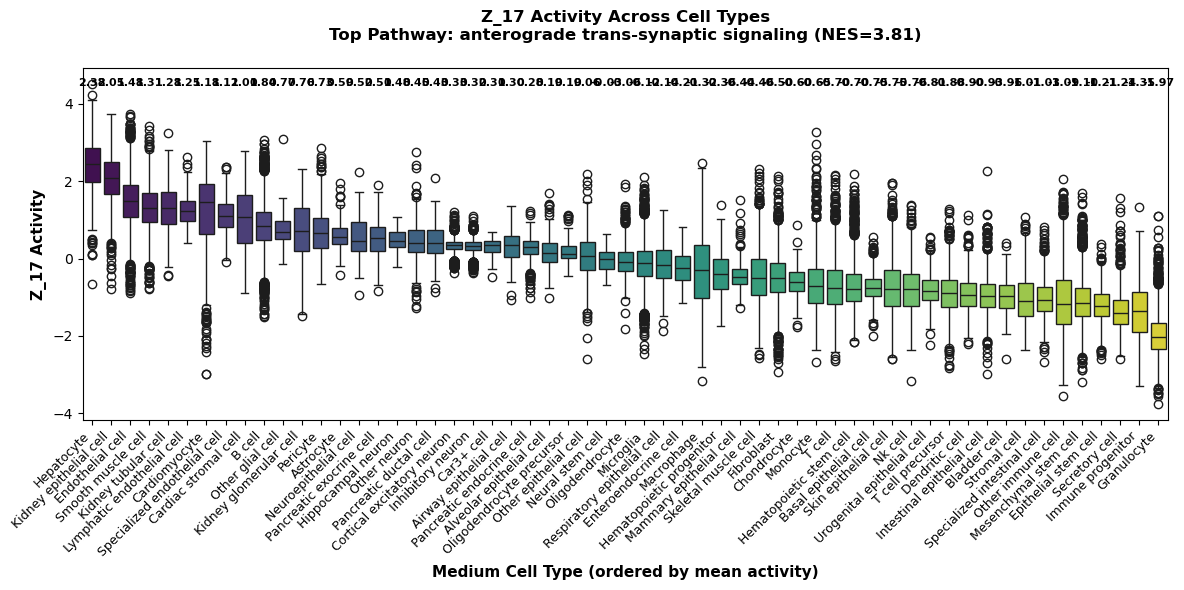

Creating plot 18/20: Z_18


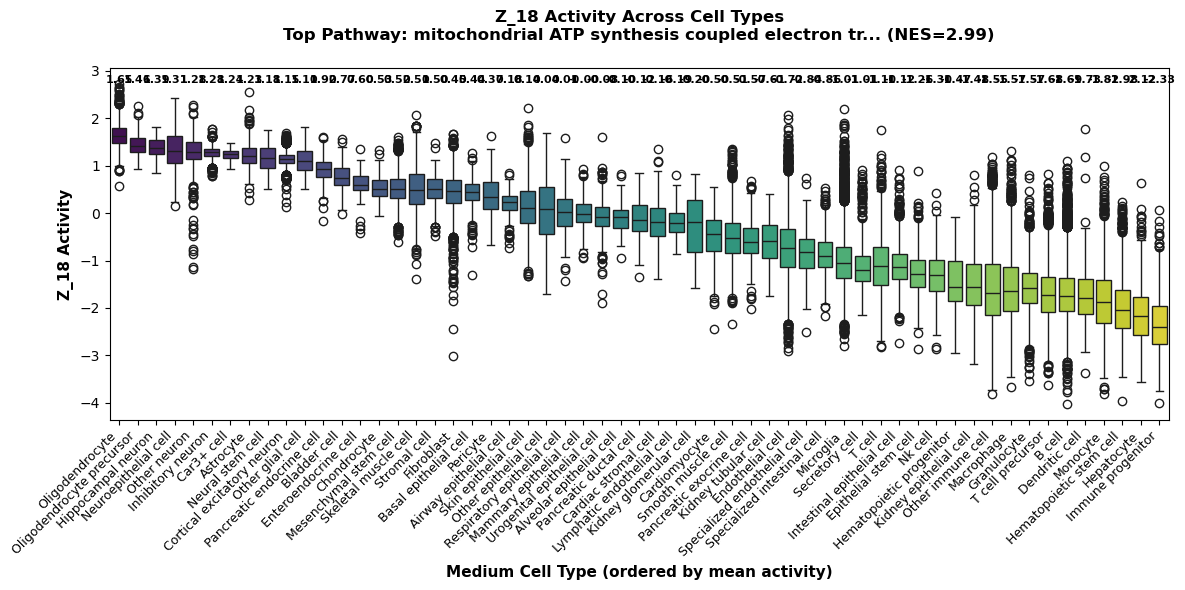

Creating plot 19/20: Z_19


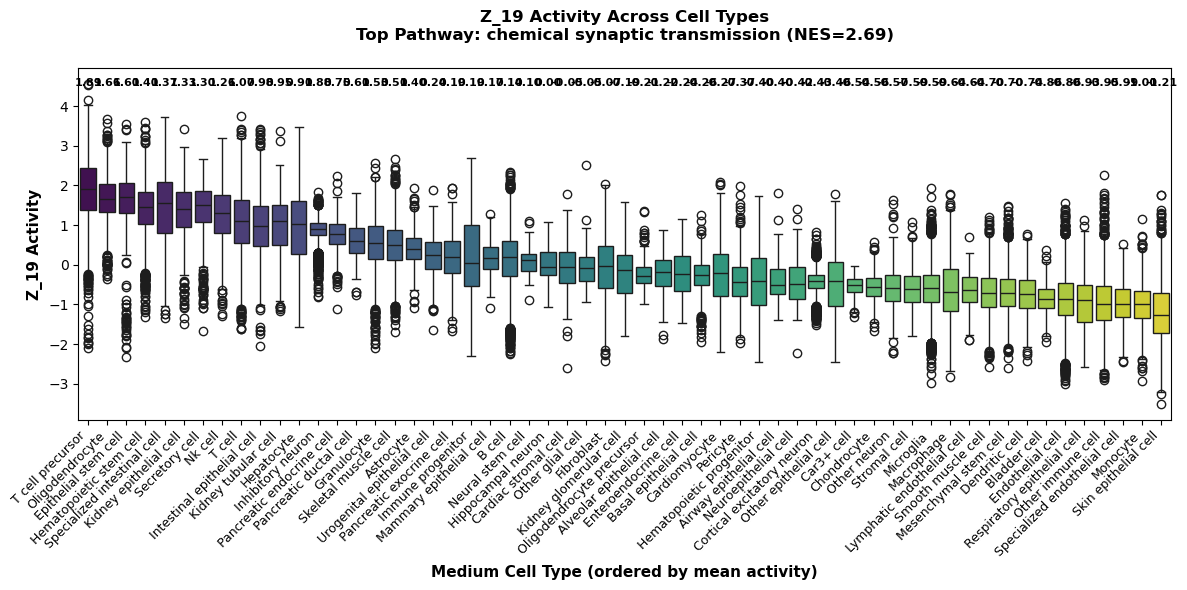

Creating plot 20/20: Z_20


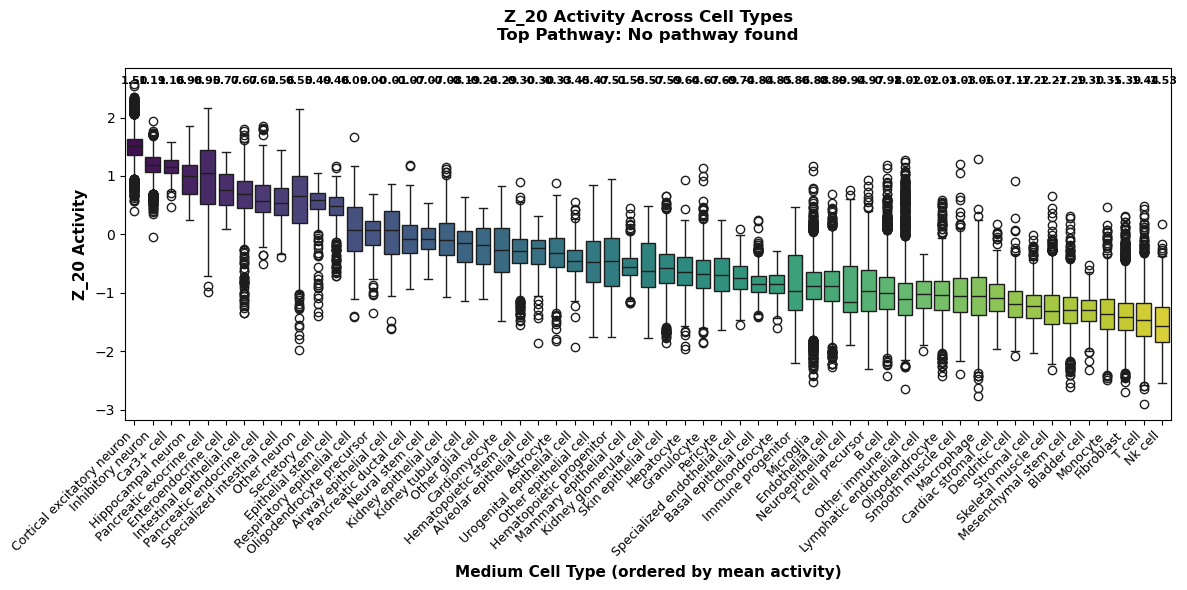


Creating enhanced summary statistics...
Enhanced summary statistics saved to: /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/scVI_factors_summary_with_pathways_ordered.csv

Sample Summary Statistics (with pathways and ranking):
Factor                                                   Top_Pathway                    Cell_Type  Activity_Rank  N_Cells      Mean    Median      Std       Min      Max
   Z_1                            cytoplasmic translation (NES=2.05)         Skeletal muscle cell              1     2469  1.793906  1.837333 0.775746 -1.373683 4.014424
   Z_1                            cytoplasmic translation (NES=2.05)        Mesenchymal stem cell              2     4780  1.310975  1.307423 0.613196 -2.445030 3.640848
   Z_1                            cytoplasmic translation (NES=2.05)                 Bladder cell              3      526  1.298630  1.303323 0.473411 -

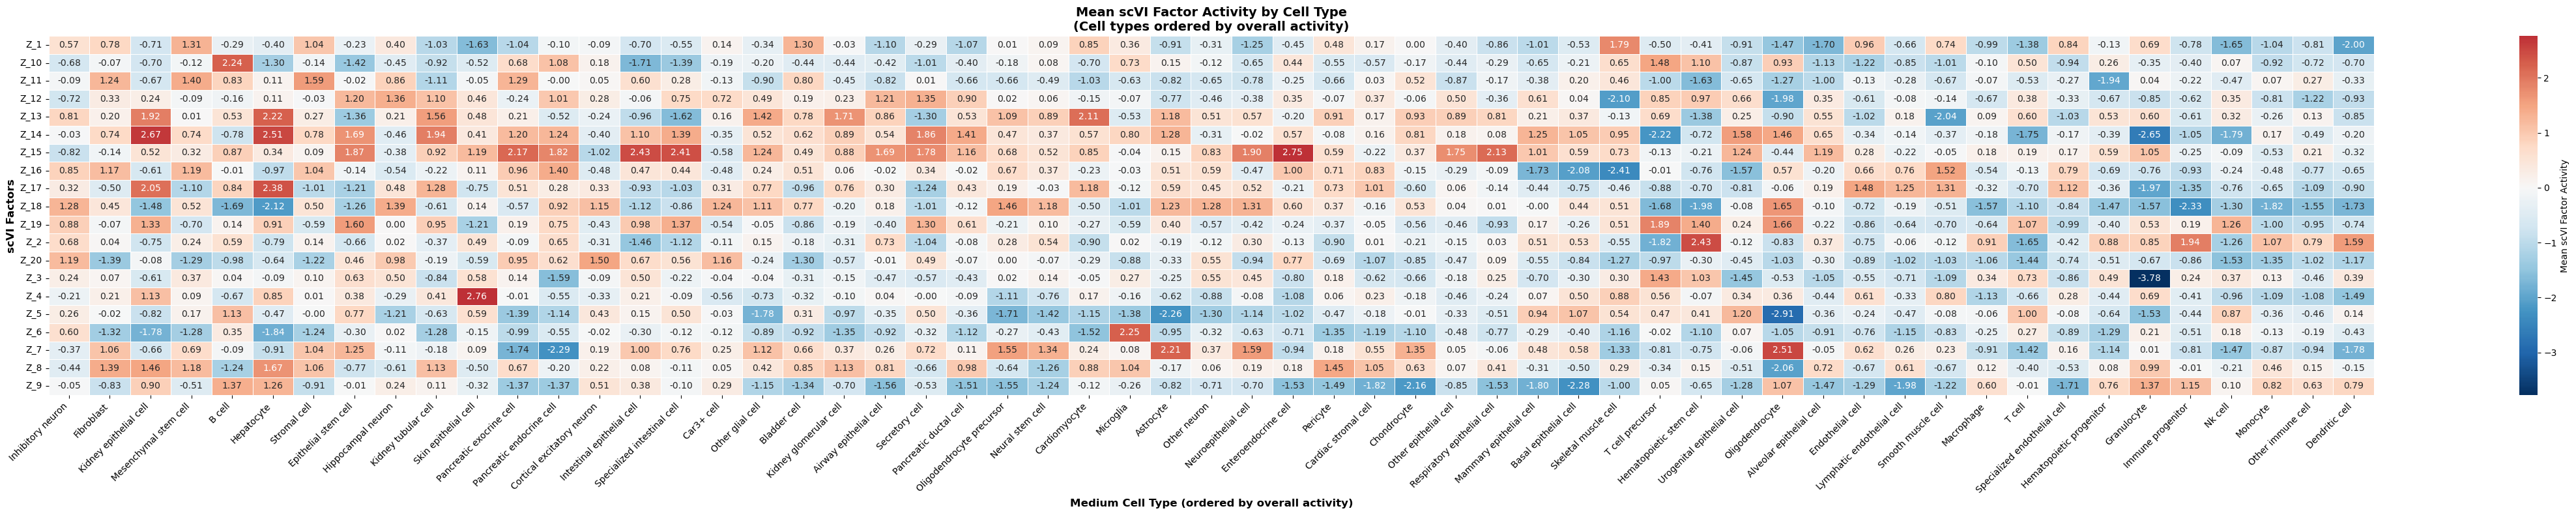


Factor-specific cell type rankings:
Factor                                                   Top_Pathway                                                      Highest_Activity_CellTypes
   Z_1                            cytoplasmic translation (NES=2.05)                     Skeletal muscle cell > Mesenchymal stem cell > Bladder cell
   Z_2 SRP-dependent cotranslational protein targeting... (NES=2.14)                    Hematopoietic stem cell > Immune progenitor > Dendritic cell
   Z_3   nuclear-transcribed mRNA poly(A) tail shortening (NES=2.72)                             T cell precursor > Hematopoietic stem cell > T cell
   Z_4                            cytoplasmic translation (NES=2.49)            Skin epithelial cell > Kidney epithelial cell > Skeletal muscle cell
   Z_5             regulation of adaptive immune response (NES=2.13)                     Urogenital epithelial cell > B cell > Basal epithelial cell
   Z_6 mitochondrial electron transport, NADH to ubiqu... (NES=2.59) 

In [96]:
# Simplified scVI Factor Activity Analysis by Medium Cell Type with GSEA Pathways
# Configuration
CELLTYPE_COL = 'medium_cell_type'  # Your column name
figsize_per_plot = (12, 6)

# Extract data
X_scVI = ge_adata.obsm["X_scVI_linear"]
n_scvi_factors = X_scVI.shape[1]
scvi_factor_names = [f"Z_{i+1}" for i in range(n_scvi_factors)]

# Get metadata
metadata_df = ge_adata.obs.copy()
print(f"Available categories in {CELLTYPE_COL}: {sorted(metadata_df[CELLTYPE_COL].unique())}")
print(f"Number of cells per category:")
print(metadata_df[CELLTYPE_COL].value_counts().sort_index())

# Create combined dataframe
scvi_df = pd.DataFrame(X_scVI, columns=scvi_factor_names, index=metadata_df.index)
combined_df = pd.concat([scvi_df, metadata_df[[CELLTYPE_COL]]], axis=1)

def get_top_pathway_for_factor(factor_name, gsea_df):
    """
    Get the top pathway for a factor from GSEA DataFrame.
    """
    factor_results = gsea_df[gsea_df['Factor'] == factor_name]
    
    if len(factor_results) > 0:
        # First try positive pathways with FDR < 0.05
        positive_results = factor_results[
            (factor_results['NES'] > 0) & 
            (factor_results['FDR q-val'] < 0.05)
        ]
        
        if len(positive_results) > 0:
            best_pathway = positive_results.loc[positive_results['FDR q-val'].idxmin()]
        else:
            # If no positive significant, get the best overall
            best_pathway = factor_results.loc[factor_results['FDR q-val'].idxmin()]
        
        # Clean pathway name
        pathway_name = best_pathway['Term']
        if '(GO:' in pathway_name:
            pathway_name = pathway_name.split('(GO:')[0].strip()
        
        # Truncate if too long
        if len(pathway_name) > 50:
            pathway_name = pathway_name[:47] + "..."
            
        return f"{pathway_name} (NES={best_pathway['NES']:.2f})"
    else:
        return "No pathway found"

def get_ordered_celltypes_for_factor(factor_name, data_df, celltype_col):
    """
    Order cell types by mean activity for this specific factor (highest to lowest).
    """
    celltype_means = data_df.groupby(celltype_col)[factor_name].mean().sort_values(ascending=False)
    return celltype_means.index.tolist()

def create_scvi_boxplot_with_pathway(factor_name, data_df, celltype_col, pathway_info, 
                                   figsize=(12, 6), save_path=None):
    """
    Create boxplot showing scVI factor activity across cell types, ordered by mean activity.
    """
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    
    # Get ordered cell types for this factor
    ordered_celltypes = get_ordered_celltypes_for_factor(factor_name, data_df, celltype_col)
    
    # Create boxplot with ordered categories
    sns.boxplot(
        data=data_df,
        x=celltype_col,
        y=factor_name,
        order=ordered_celltypes,  # Order by mean activity
        ax=ax,
        palette='viridis'  # Color gradient that matches the ordering
    )
    
    # Enhanced title with pathway information
    title = f'{factor_name} Activity Across Cell Types\nTop Pathway: {pathway_info}'
    ax.set_title(title, fontsize=12, fontweight='bold', pad=20)
    ax.set_xlabel('Medium Cell Type (ordered by mean activity)', fontsize=11, fontweight='bold')
    ax.set_ylabel(f'{factor_name} Activity', fontsize=11, fontweight='bold')
    
    # Rotate x-axis labels for readability
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
    
    # Add mean values as text annotations on top of boxes
    for i, celltype in enumerate(ordered_celltypes):
        mean_val = data_df[data_df[celltype_col] == celltype][factor_name].mean()
        ax.text(i, ax.get_ylim()[1] * 0.95, f'{mean_val:.2f}', 
                ha='center', va='top', fontweight='bold', fontsize=8)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
    
    return fig

# Load GSEA results
gsea_results = GSEA_scVI_full

print(f"\nCreating boxplots for all {n_scvi_factors} scVI factors with pathway information...")

# Create pathway lookup for all factors
pathway_info = {}
for factor_name in scvi_factor_names:
    pathway_info[factor_name] = get_top_pathway_for_factor(factor_name, gsea_results)

# Show pathway summary
print("\nTop pathways for each factor:")
for factor, pathway in pathway_info.items():
    print(f"  {factor}: {pathway}")

# Create plots for all scVI factors
for i, factor_name in enumerate(scvi_factor_names):
    print(f"Creating plot {i+1}/{n_scvi_factors}: {factor_name}")
    
    fig = create_scvi_boxplot_with_pathway(
        factor_name=factor_name,
        data_df=combined_df,
        celltype_col=CELLTYPE_COL,
        pathway_info=pathway_info[factor_name],
        figsize=figsize_per_plot,
        save_path=os.path.join(OUTPUT_DIR, f"scVI_{factor_name}_boxplot_with_pathway.pdf")
    )
    
    plt.show()
    plt.close(fig)

# Create enhanced summary statistics with pathway information and ordering
print("\nCreating enhanced summary statistics...")
summary_stats = []

for factor in scvi_factor_names:
    # Get pathway info for this factor
    factor_pathway = pathway_info[factor]
    
    # Get ordered cell types for this factor
    ordered_celltypes = get_ordered_celltypes_for_factor(factor, combined_df, CELLTYPE_COL)
    
    for rank, celltype in enumerate(ordered_celltypes, 1):
        subset = combined_df[combined_df[CELLTYPE_COL] == celltype]
        values = subset[factor].values
        
        summary_stats.append({
            'Factor': factor,
            'Top_Pathway': factor_pathway,
            'Cell_Type': celltype,
            'Activity_Rank': rank,  # 1 = highest mean activity for this factor
            'N_Cells': len(values),
            'Mean': np.mean(values),
            'Median': np.median(values),
            'Std': np.std(values),
            'Min': np.min(values),
            'Max': np.max(values)
        })

summary_df = pd.DataFrame(summary_stats)

# Save enhanced summary statistics
summary_path = os.path.join(OUTPUT_DIR, "scVI_factors_summary_with_pathways_ordered.csv")
summary_df.to_csv(summary_path, index=False)
print(f"Enhanced summary statistics saved to: {summary_path}")

# Show sample of summary stats
print("\nSample Summary Statistics (with pathways and ranking):")
sample_df = summary_df[summary_df['Factor'].isin(['Z_1', 'Z_2', 'Z_3'])].copy()
print(sample_df.to_string(index=False))

# Create overview heatmap showing mean activity per factor per cell type (ordered)
print("\nCreating overview heatmap with ordered cell types...")

# Create a matrix where cell types are ordered by overall activity across all factors
overall_celltype_activity = combined_df.groupby(CELLTYPE_COL)[scvi_factor_names].mean().mean(axis=1)
overall_ordered_celltypes = overall_celltype_activity.sort_values(ascending=False).index.tolist()

# Create pivot table with overall ordering
pivot_df = summary_df.pivot(index='Factor', columns='Cell_Type', values='Mean')
pivot_df = pivot_df[overall_ordered_celltypes]  # Reorder columns

plt.figure(figsize=(max(12, len(overall_ordered_celltypes) * 0.8), max(8, n_scvi_factors * 0.4)))
sns.heatmap(
    pivot_df,
    cmap='RdBu_r',
    center=0,
    annot=True,
    fmt='.2f',
    cbar_kws={'label': 'Mean scVI Factor Activity'},
    linewidths=0.5
)

plt.title('Mean scVI Factor Activity by Cell Type\n(Cell types ordered by overall activity)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Medium Cell Type (ordered by overall activity)', fontsize=12, fontweight='bold')
plt.ylabel('scVI Factors', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

heatmap_path = os.path.join(OUTPUT_DIR, "scVI_factors_heatmap_overview_ordered.pdf")
plt.savefig(heatmap_path, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# Create a factor-specific ordering summary
print("\nFactor-specific cell type rankings:")
ranking_summary = []
for factor in scvi_factor_names:
    factor_data = summary_df[summary_df['Factor'] == factor].sort_values('Activity_Rank')
    top_3_celltypes = factor_data.head(3)['Cell_Type'].tolist()
    pathway = factor_data.iloc[0]['Top_Pathway']
    
    ranking_summary.append({
        'Factor': factor,
        'Top_Pathway': pathway,
        'Highest_Activity_CellTypes': ' > '.join(top_3_celltypes)
    })

ranking_df = pd.DataFrame(ranking_summary)
print(ranking_df.to_string(index=False))

# Save ranking summary
ranking_path = os.path.join(OUTPUT_DIR, "scVI_factors_celltype_rankings.csv")
ranking_df.to_csv(ranking_path, index=False)

print(f"\nAnalysis complete!")
print(f"Created {n_scvi_factors} individual boxplots with pathway information")
print(f"Enhanced summary with pathways saved to: {summary_path}")
print(f"Ordered overview heatmap saved to: {heatmap_path}")
print(f"Factor-specific rankings saved to: {ranking_path}")